# 1. Exploratory Data Analysis & Pre-processing

## 1.1 Configurations

In [1]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 11.7 MB/s eta 0:00:00


In [2]:
# Import Libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, optimizers, callbacks
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from collections import Counter
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
import optuna

import warnings
warnings.filterwarnings('ignore')

# Set random seed
tf.random.set_seed(42)
np.random.seed(42)

# Global matplotlib settings
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11

print("All libraries imported successfully.")
print(f"TensorFlow version: {tf.__version__}")

All libraries imported successfully.
TensorFlow version: 2.20.0


In [3]:
# Load MNIST dataset from Keras
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

print("MNIST dataset loaded successfully!")
print()
print("=" * 52)
print("  TRAINING SET")
print(f"  X_train shape : {X_train.shape}  -> (n_images, height, width)")
print(f"  y_train shape : {y_train.shape}   -> (n_labels,)")
print("=" * 52)
print("  TEST SET")
print(f"  X_test shape  : {X_test.shape}")
print(f"  y_test shape  : {y_test.shape}")
print("=" * 52)
print()
print(f"  Pixel data type   : {X_train.dtype}  (integer values 0–255)")
print(f"  Pixel value min   : {X_train.min()}")
print(f"  Pixel value max   : {X_train.max()}")
print(f"  Unique labels     : {np.unique(y_train)}")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
MNIST dataset loaded successfully!

  TRAINING SET
  X_train shape : (60000, 28, 28)  -> (n_images, height, width)
  y_train shape : (60000,)   -> (n_labels,)
  TEST SET
  X_test shape  : (10000, 28, 28)
  y_test shape  : (10000,)

  Pixel data type   : uint8  (integer values 0–255)
  Pixel value min   : 0
  Pixel value max   : 255
  Unique labels     : [0 1 2 3 4 5 6 7 8 9]


## 1.2 CLass Distribution Analysis

In [4]:
# Count the number of samples per class in training and test sets
unique_labels, train_counts = np.unique(y_train, return_counts=True)
_, test_counts = np.unique(y_test, return_counts=True)

# Print detailed statistics table
print("CLASS DISTRIBUTION IN DATASET")
print("-" * 48)
print(f"  {'Digit':>6} | {'Train':>8} | {'Test':>7} | {'Train %':>9}")
print("-" * 48)
for label, tc, tec in zip(unique_labels, train_counts, test_counts):
    pct = tc / len(y_train) * 100
    print(f"  {'Digit ' + str(label):>6} | {tc:>8,} | {tec:>7,} | {pct:>8.1f}%")
print("-" * 48)
print(f"  {'TOTAL':>6} | {sum(train_counts):>8,} | {sum(test_counts):>7,} | {'100.0%':>9}")

CLASS DISTRIBUTION IN DATASET
------------------------------------------------
   Digit |    Train |    Test |   Train %
------------------------------------------------
  Digit 0 |    5,923 |     980 |      9.9%
  Digit 1 |    6,742 |   1,135 |     11.2%
  Digit 2 |    5,958 |   1,032 |      9.9%
  Digit 3 |    6,131 |   1,010 |     10.2%
  Digit 4 |    5,842 |     982 |      9.7%
  Digit 5 |    5,421 |     892 |      9.0%
  Digit 6 |    5,918 |     958 |      9.9%
  Digit 7 |    6,265 |   1,028 |     10.4%
  Digit 8 |    5,851 |     974 |      9.8%
  Digit 9 |    5,949 |   1,009 |      9.9%
------------------------------------------------
   TOTAL |   60,000 |  10,000 |    100.0%


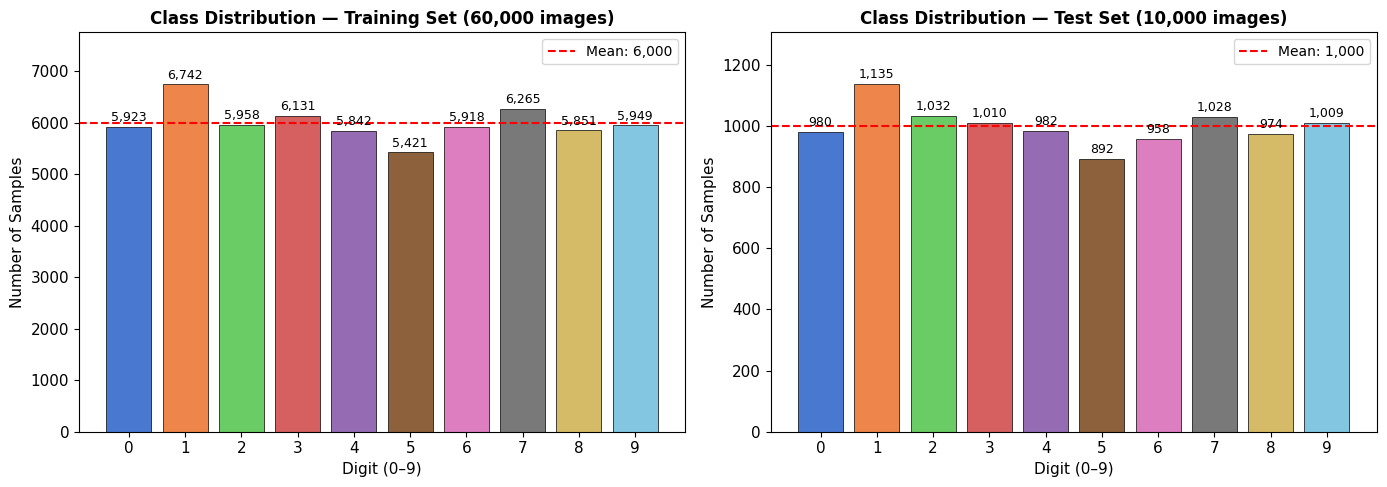


FINDING:
  - Sample count per class ranges from 5,421 to 6,742
  - Max-min difference: 1,321 images
  - Deviation from mean: 22.0%
  => Dataset is WELL-BALANCED. No oversampling or undersampling required.


In [5]:
# Visualize class distribution — Training and Test sets side by side

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = sns.color_palette("muted", 10)

# --- Plot 1: Training Set ---
bars = axes[0].bar(unique_labels, train_counts, color=colors, edgecolor='black', linewidth=0.5)
axes[0].set_title('Class Distribution — Training Set (60,000 images)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Digit (0–9)', fontsize=11)
axes[0].set_ylabel('Number of Samples', fontsize=11)
axes[0].set_xticks(unique_labels)
axes[0].set_ylim(0, max(train_counts) * 1.15)

for bar, count in zip(bars, train_counts):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                 f'{count:,}', ha='center', va='bottom', fontsize=9)

mean_train = np.mean(train_counts)
axes[0].axhline(y=mean_train, color='red', linestyle='--', linewidth=1.5,
                label=f'Mean: {mean_train:,.0f}')
axes[0].legend(fontsize=10)

# --- Plot 2: Test Set ---
bars2 = axes[1].bar(unique_labels, test_counts, color=colors, edgecolor='black', linewidth=0.5)
axes[1].set_title('Class Distribution — Test Set (10,000 images)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Digit (0–9)', fontsize=11)
axes[1].set_ylabel('Number of Samples', fontsize=11)
axes[1].set_xticks(unique_labels)
axes[1].set_ylim(0, max(test_counts) * 1.15)

for bar, count in zip(bars2, test_counts):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                 f'{count:,}', ha='center', va='bottom', fontsize=9)

mean_test = np.mean(test_counts)
axes[1].axhline(y=mean_test, color='red', linestyle='--', linewidth=1.5,
                label=f'Mean: {mean_test:,.0f}')
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.show()

print()
print("FINDING:")
print(f"  - Sample count per class ranges from {min(train_counts):,} to {max(train_counts):,}")
print(f"  - Max-min difference: {max(train_counts) - min(train_counts):,} images")
print(f"  - Deviation from mean: {(max(train_counts)-min(train_counts))/mean_train*100:.1f}%")
print(f"  => Dataset is WELL-BALANCED. No oversampling or undersampling required.")

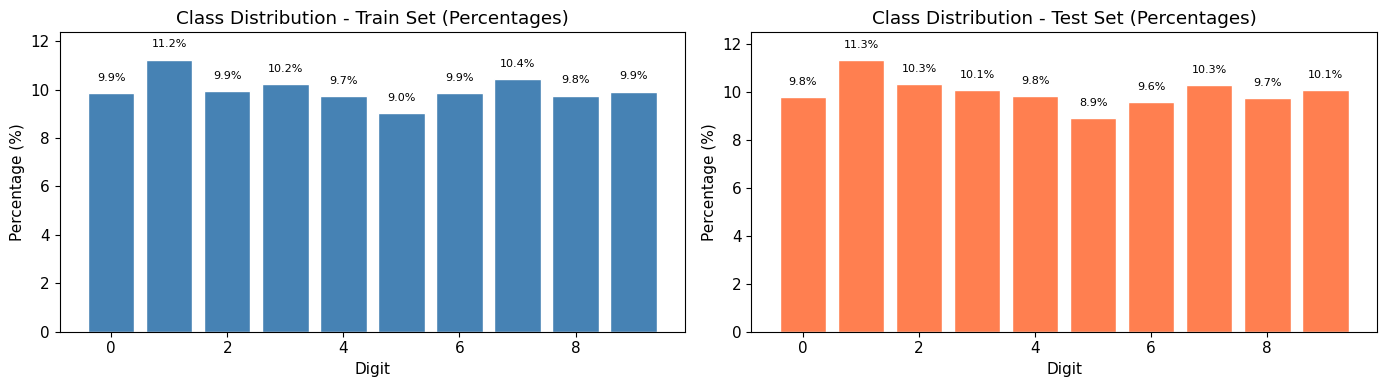

In [6]:
# In percentages
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Train set
counts_train = Counter(y_train)
total_train = sum(counts_train.values())
train_percentages = {k: (v / total_train) * 100 for k, v in counts_train.items()}

axes[0].bar(train_percentages.keys(), train_percentages.values(), color='steelblue', edgecolor='white')
axes[0].set_title("Class Distribution - Train Set (Percentages)")
axes[0].set_xlabel("Digit")
axes[0].set_ylabel("Percentage (%)")
axes[0].set_ylim(0, max(train_percentages.values()) * 1.1) # Adjust y-limit for better visualization
for k, v in train_percentages.items():
    axes[0].text(k, v + 0.5, f"{v:.1f}%", ha='center', fontsize=8) # Display percentages

# Test set
counts_test = Counter(y_test)
total_test = sum(counts_test.values())
test_percentages = {k: (v / total_test) * 100 for k, v in counts_test.items()}

axes[1].bar(test_percentages.keys(), test_percentages.values(), color='coral', edgecolor='white')
axes[1].set_title("Class Distribution - Test Set (Percentages)")
axes[1].set_xlabel("Digit")
axes[1].set_ylabel("Percentage (%)") # Add y-axis label for test set
axes[1].set_ylim(0, max(test_percentages.values()) * 1.1) # Adjust y-limit for better visualization
for k, v in test_percentages.items():
    axes[1].text(k, v + 0.5, f"{v:.1f}%", ha='center', fontsize=8) # Display percentages


plt.tight_layout()
plt.show()

## 1.3 Sample Visualization

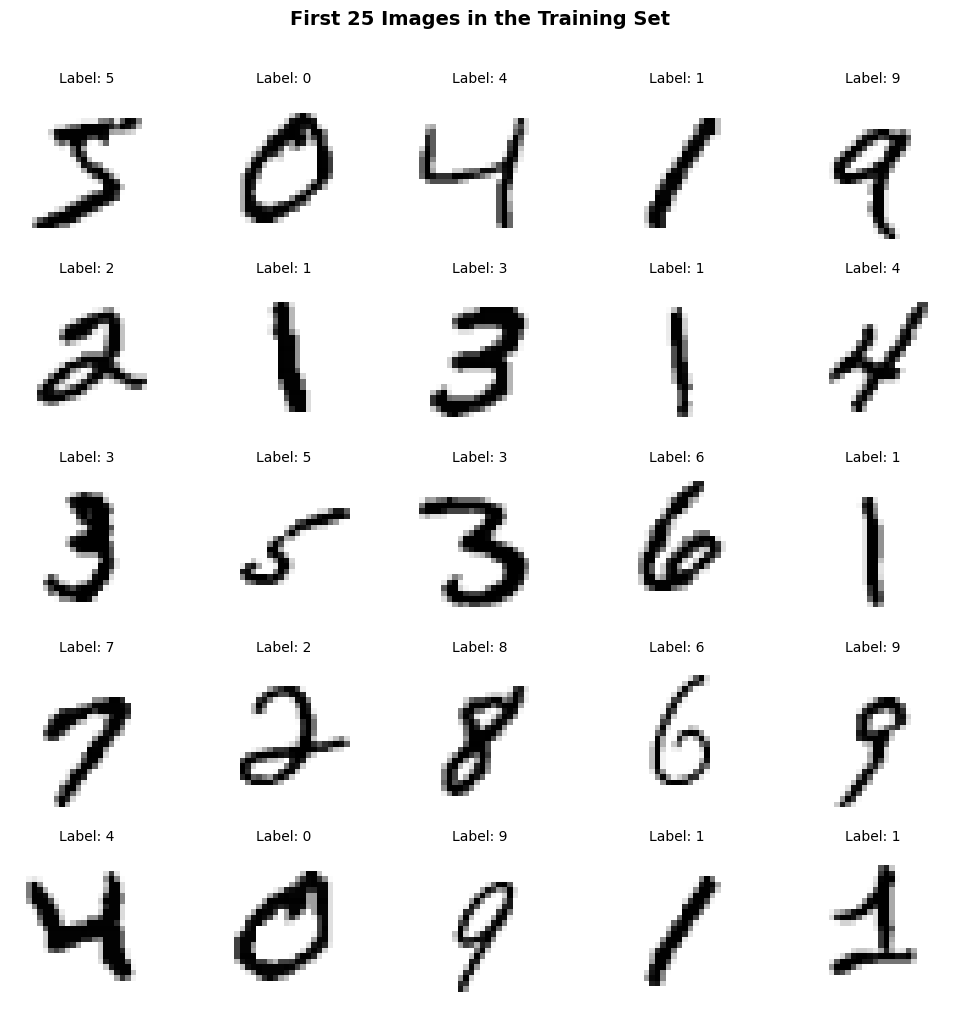

Observation: Digits are written in diverse styles — this is the real-world characteristic of handwritten data.


In [7]:
# Display the first 25 images from the training set in a 5x5 grid

fig, axes = plt.subplots(5, 5, figsize=(10, 10))
fig.suptitle('First 25 Images in the Training Set', fontsize=14, fontweight='bold', y=1.01)

for i, ax in enumerate(axes.flat):
    ax.imshow(X_train[i], cmap='binary')
    ax.set_title(f'Label: {y_train[i]}', fontsize=10)
    ax.axis('off')

plt.tight_layout()
plt.show()
print("Observation: Digits are written in diverse styles — this is the real-world characteristic of handwritten data.")

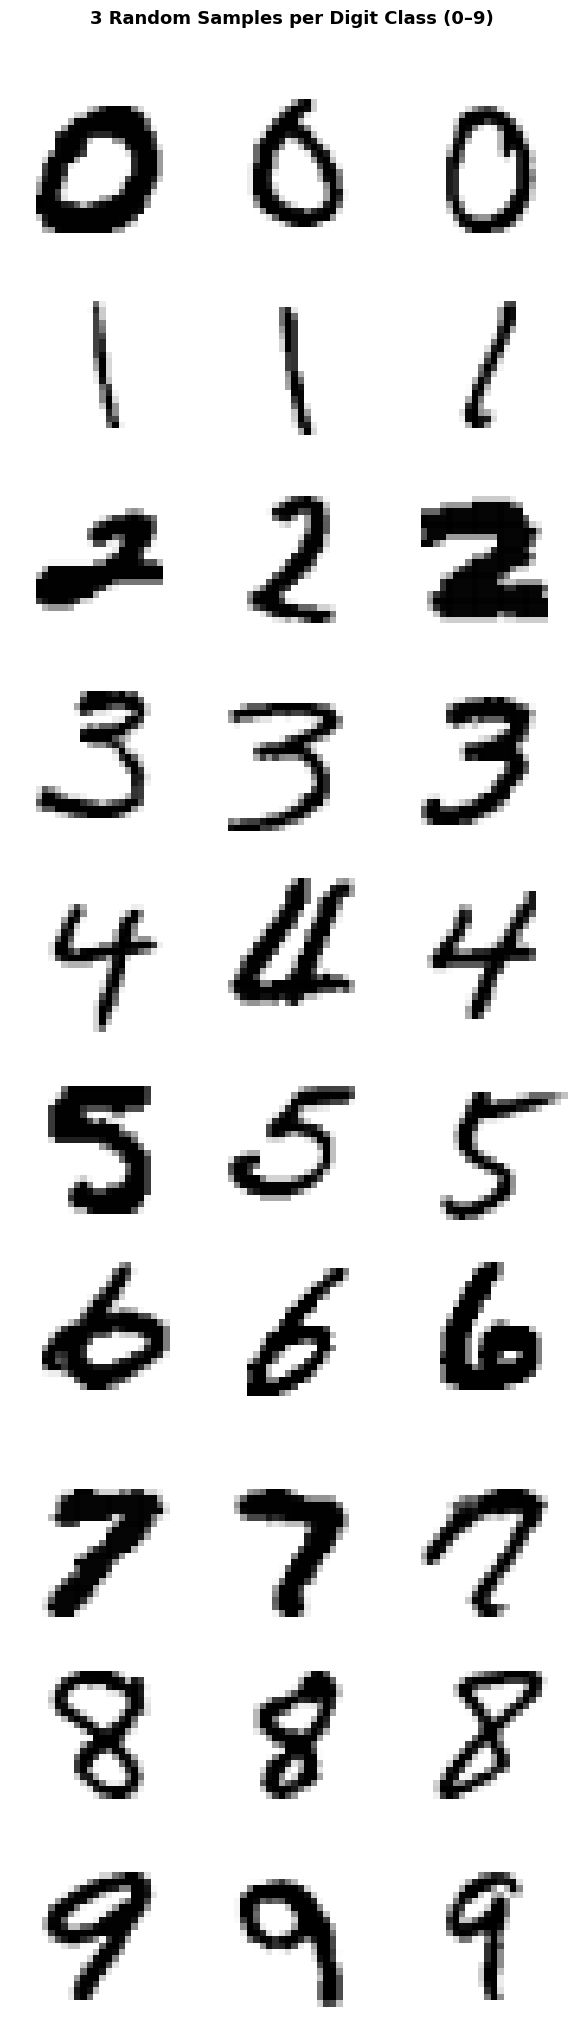

Observation: The same digit can appear in many stroke styles.
=> A good model must learn generalized features, not memorize specific handwriting.


In [8]:
# Display 3 random samples for each digit class (0–9)
# Purpose: visualize intra-class variation

fig, axes = plt.subplots(10, 3, figsize=(6, 20))
fig.suptitle('3 Random Samples per Digit Class (0–9)', fontsize=13, fontweight='bold', y=1.01)

np.random.seed(42)  # Fixed seed for reproducibility

for digit in range(10):
    indices = np.where(y_train == digit)[0]
    sample_indices = np.random.choice(indices, 3, replace=False)

    for col, idx in enumerate(sample_indices):
        axes[digit, col].imshow(X_train[idx], cmap='binary')
        axes[digit, col].axis('off')
        if col == 0:
            axes[digit, col].set_ylabel(f'Digit {digit}', fontsize=11,
                                        rotation=0, labelpad=35, va='center')

plt.tight_layout()
plt.show()
print("Observation: The same digit can appear in many stroke styles.")
print("=> A good model must learn generalized features, not memorize specific handwriting.")

## 1.4 Average Digit Images (Prototypical Shapes)

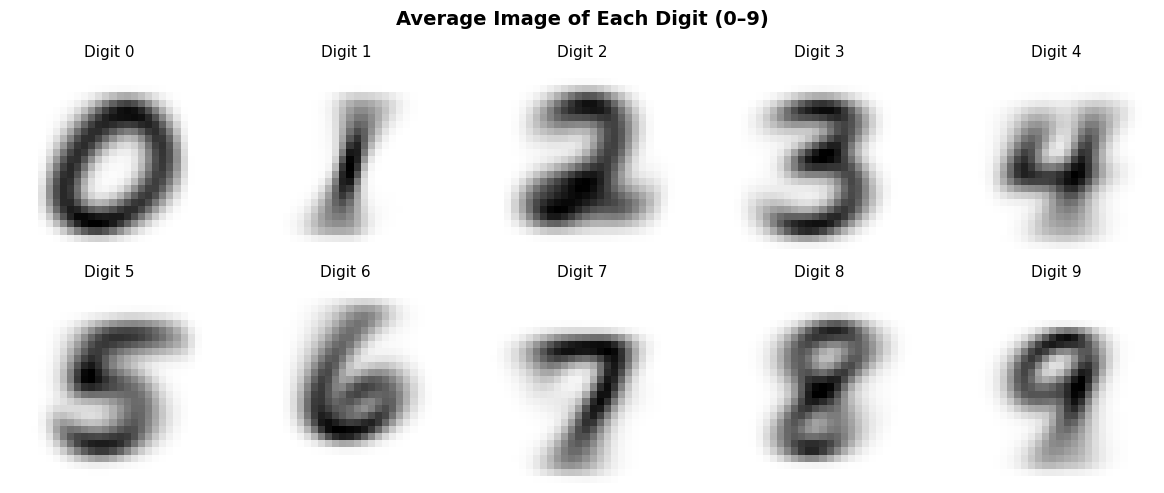

FINDING:
  - Clear, sharp average images indicate low intra-class variation (e.g., digit 1).
  - Blurry/diffuse average images indicate high variation in writing style (e.g., digit 2, 7).
  - Visually similar averages (e.g., 4 vs 9, 3 vs 8) suggest potential confusion points for the model.


In [9]:
# Save the original uint8 array before normalization (used here and in sparsity analysis)
X_train_original = X_train.copy()

# Compute and display the average image for each digit class
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
fig.suptitle('Average Image of Each Digit (0–9)', fontsize=14, fontweight='bold')

for digit in range(10):
    # Compute pixel-wise mean across all images of this digit
    avg_img = X_train_original[y_train == digit].mean(axis=0)  # shape: (28, 28)
    ax = axes[digit // 5, digit % 5]
    ax.imshow(avg_img, cmap='binary')
    ax.set_title(f'Digit {digit}', fontsize=11)
    ax.axis('off')

plt.tight_layout()
plt.show()

print("FINDING:")
print("  - Clear, sharp average images indicate low intra-class variation (e.g., digit 1).")
print("  - Blurry/diffuse average images indicate high variation in writing style (e.g., digit 2, 7).")
print("  - Visually similar averages (e.g., 4 vs 9, 3 vs 8) suggest potential confusion points for the model.")

## 1.5 Pixel Value Analysis

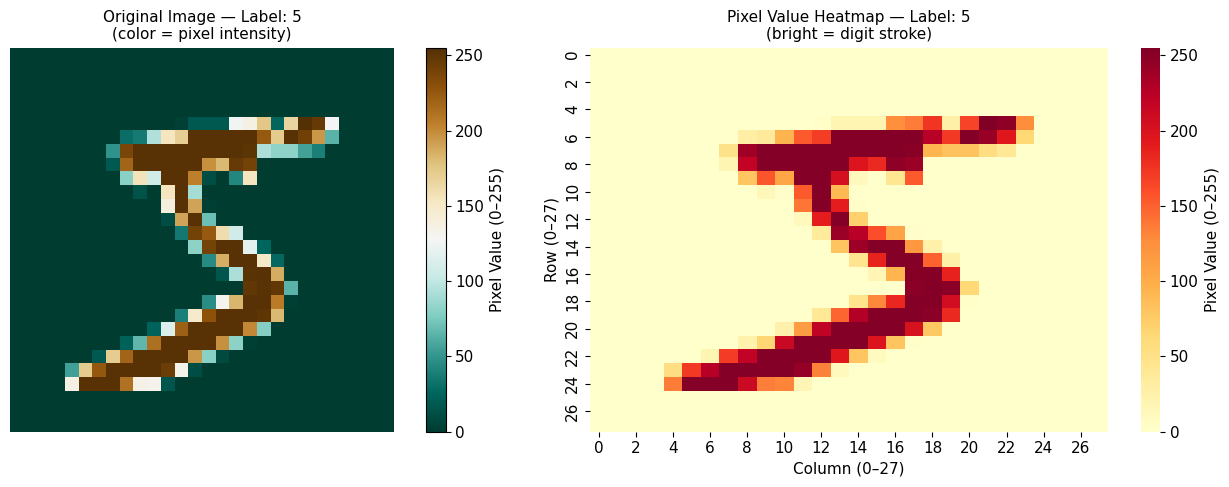

Pixel statistics for image #0 (label = 5):
  Min value       : 0
  Max value       : 255
  Mean            : 35.11
  Std deviation   : 79.65
  % pixels = 0    : 78.8% (background)


In [10]:
# Examine pixel values of the first image in detail

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Image with BrBG_r colormap (highlights stroke vs background contrast)
im1 = axes[0].imshow(X_train_original[0], cmap='BrBG_r')
axes[0].set_title(f'Original Image — Label: {y_train[0]}\n(color = pixel intensity)', fontsize=11)
axes[0].axis('off')
plt.colorbar(im1, ax=axes[0], label='Pixel Value (0–255)')

# Heatmap of pixel values
sns.heatmap(X_train_original[0], annot=False, cmap='YlOrRd',
            ax=axes[1], cbar_kws={'label': 'Pixel Value (0–255)'})
axes[1].set_title(f'Pixel Value Heatmap — Label: {y_train[0]}\n(bright = digit stroke)', fontsize=11)
axes[1].set_xlabel('Column (0–27)')
axes[1].set_ylabel('Row (0–27)')

plt.tight_layout()
plt.show()

print(f"Pixel statistics for image #0 (label = {y_train[0]}):")
print(f"  Min value       : {X_train_original[0].min()}")
print(f"  Max value       : {X_train_original[0].max()}")
print(f"  Mean            : {X_train_original[0].mean():.2f}")
print(f"  Std deviation   : {X_train_original[0].std():.2f}")
print(f"  % pixels = 0    : {(X_train_original[0] == 0).sum() / X_train_original[0].size * 100:.1f}% (background)")

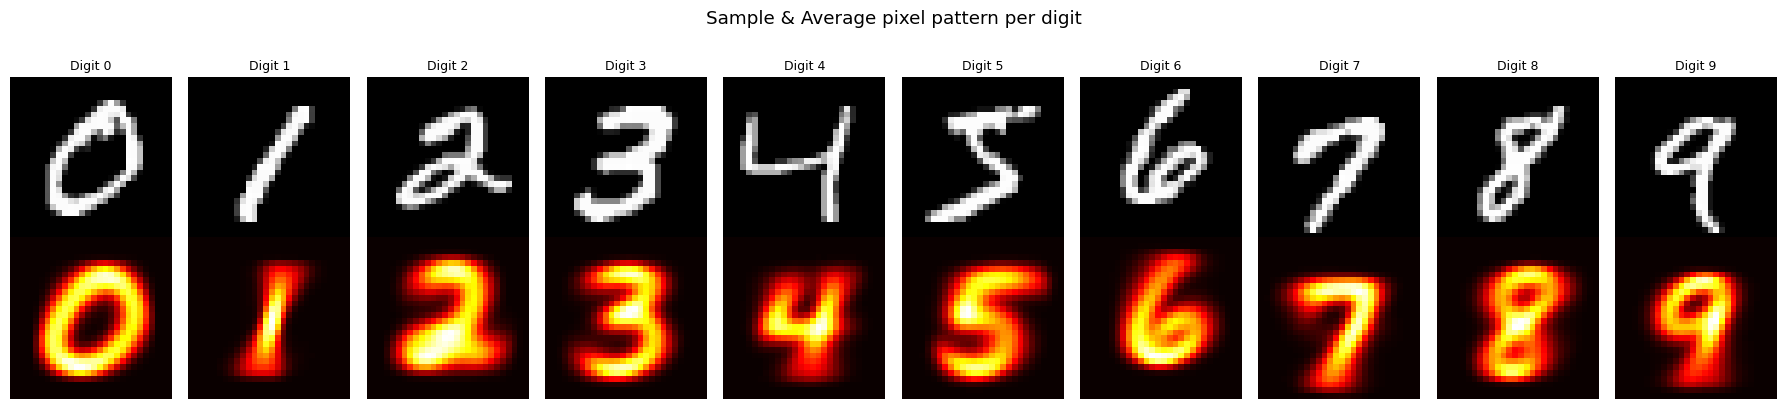

In [11]:
fig, axes = plt.subplots(2, 10, figsize=(18, 4))

for digit in range(10):
    idx = np.where(y_train == digit)[0]

    # Row 1: random sample value
    sample = X_train[idx[0]]
    axes[0, digit].imshow(sample, cmap='gray')
    axes[0, digit].set_title(f"Digit {digit}", fontsize=9)
    axes[0, digit].axis('off')

    # Row 2: Pixel mean
    mean_img = X_train[idx].mean(axis=0)
    axes[1, digit].imshow(mean_img, cmap='hot')
    axes[1, digit].axis('off')

axes[0, 0].set_ylabel("Sample", fontsize=9)
axes[1, 0].set_ylabel("Mean pixel", fontsize=9)
plt.suptitle("Sample & Average pixel pattern per digit", y=1.02)
plt.tight_layout()
plt.show()

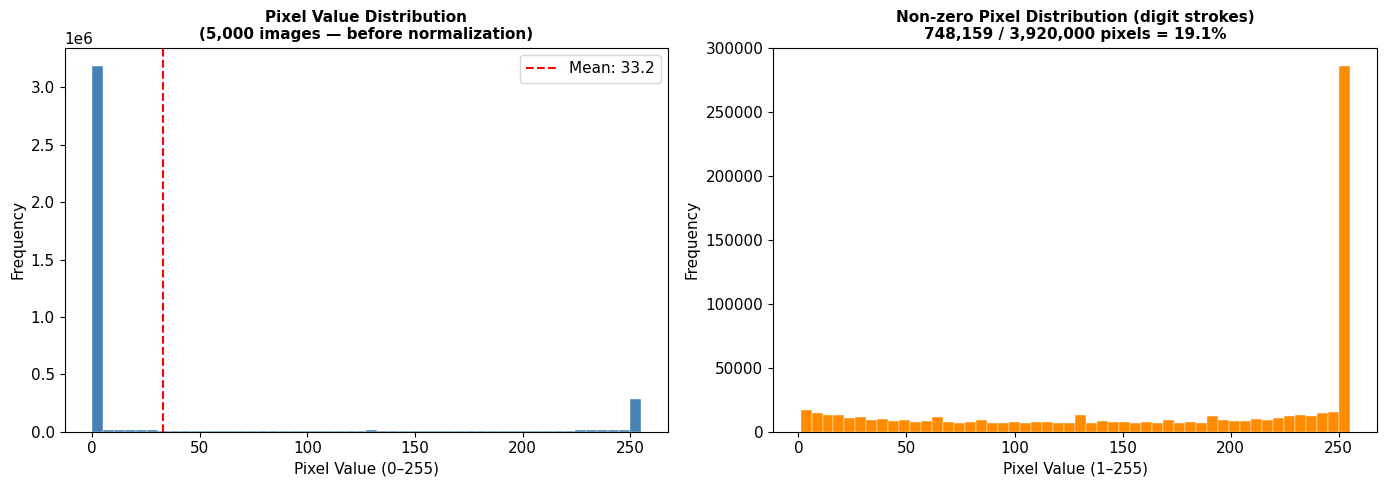

FINDING:
  - Background pixels (= 0): 80.9% of all pixels
  - Digit stroke pixels (> 0): 19.1%
  => Distribution is highly right-skewed — typical for handwritten digit images.
  => Normalization is essential for stable gradient descent.


In [12]:
# Pixel value distribution across 5,000 training images (sampled to avoid memory overload)

sample_pixels = X_train_original[:5000].flatten()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram: all pixels (including background zeros)
axes[0].hist(sample_pixels, bins=50, color='steelblue', edgecolor='white', linewidth=0.3)
axes[0].set_title('Pixel Value Distribution\n(5,000 images — before normalization)', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Pixel Value (0–255)')
axes[0].set_ylabel('Frequency')
axes[0].axvline(x=sample_pixels.mean(), color='red', linestyle='--',
                label=f'Mean: {sample_pixels.mean():.1f}')
axes[0].legend()

# Histogram: non-zero pixels only (digit strokes)
nonzero_pixels = sample_pixels[sample_pixels > 0]
axes[1].hist(nonzero_pixels, bins=50, color='darkorange', edgecolor='white', linewidth=0.3)
axes[1].set_title(
    f'Non-zero Pixel Distribution (digit strokes)\n{len(nonzero_pixels):,} / {len(sample_pixels):,} pixels = {len(nonzero_pixels)/len(sample_pixels)*100:.1f}%',
    fontsize=11, fontweight='bold')
axes[1].set_xlabel('Pixel Value (1–255)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

print("FINDING:")
print(f"  - Background pixels (= 0): {(sample_pixels==0).sum()/len(sample_pixels)*100:.1f}% of all pixels")
print(f"  - Digit stroke pixels (> 0): {len(nonzero_pixels)/len(sample_pixels)*100:.1f}%")
print(f"  => Distribution is highly right-skewed — typical for handwritten digit images.")
print(f"  => Normalization is essential for stable gradient descent.")

## 1.6 Sparsity Analysis

SPARSITY ANALYSIS
---------------------------------------------
  Mean % background pixels (whole dataset) : 80.9%
  Most sparse image (least ink)            : 95.7% zeros
  Most dense image (most ink)              : 55.2% zeros
  Std deviation across images              : 5.3%
---------------------------------------------


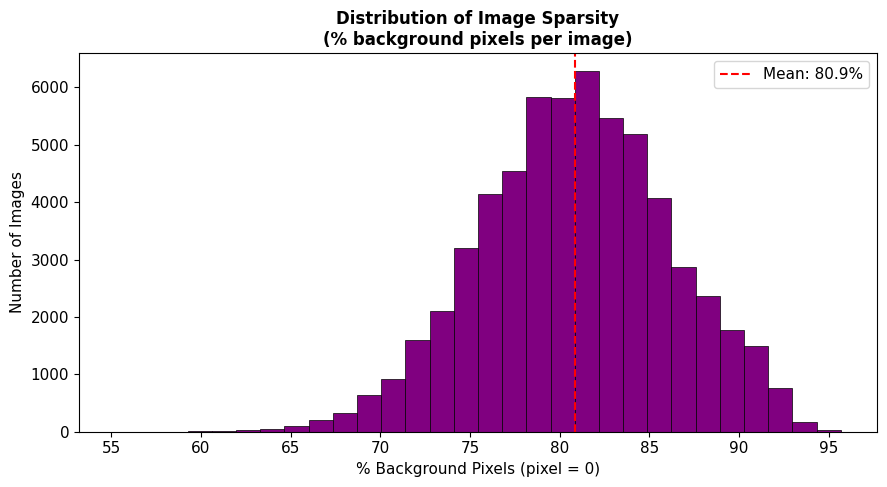


FINDING:
  - On average, 80.9% of each image is pure background.
  => Images are extremely sparse — only a small region contains digit information.
  => This sparsity directly justifies why normalization stabilizes gradient descent,
     and why CNN convolutional filters are effective at extracting localized features.


In [13]:
# Compute per-image sparsity: proportion of zero pixels for each image
# axis=(1,2) means we compute across height and width dimensions, keeping one value per image
zero_ratio = (X_train_original == 0).mean(axis=(1, 2))  # shape: (60000,)

print("SPARSITY ANALYSIS")
print("-" * 45)
print(f"  Mean % background pixels (whole dataset) : {zero_ratio.mean()*100:.1f}%")
print(f"  Most sparse image (least ink)            : {zero_ratio.max()*100:.1f}% zeros")
print(f"  Most dense image (most ink)              : {zero_ratio.min()*100:.1f}% zeros")
print(f"  Std deviation across images              : {zero_ratio.std()*100:.1f}%")
print("-" * 45)

# Distribution of sparsity across all training images
plt.figure(figsize=(9, 5))
plt.hist(zero_ratio * 100, bins=30, color='purple', edgecolor='black', linewidth=0.5)
plt.title('Distribution of Image Sparsity\n(% background pixels per image)', fontsize=12, fontweight='bold')
plt.xlabel('% Background Pixels (pixel = 0)')
plt.ylabel('Number of Images')
plt.axvline(zero_ratio.mean()*100, color='red', linestyle='--',
            label=f'Mean: {zero_ratio.mean()*100:.1f}%')
plt.legend()
plt.tight_layout()
plt.show()

print()
print("FINDING:")
print(f"  - On average, {zero_ratio.mean()*100:.1f}% of each image is pure background.")
print(f"  => Images are extremely sparse — only a small region contains digit information.")
print(f"  => This sparsity directly justifies why normalization stabilizes gradient descent,")
print(f"     and why CNN convolutional filters are effective at extracting localized features.")

## 1.7 Row & Column Activity Analysis

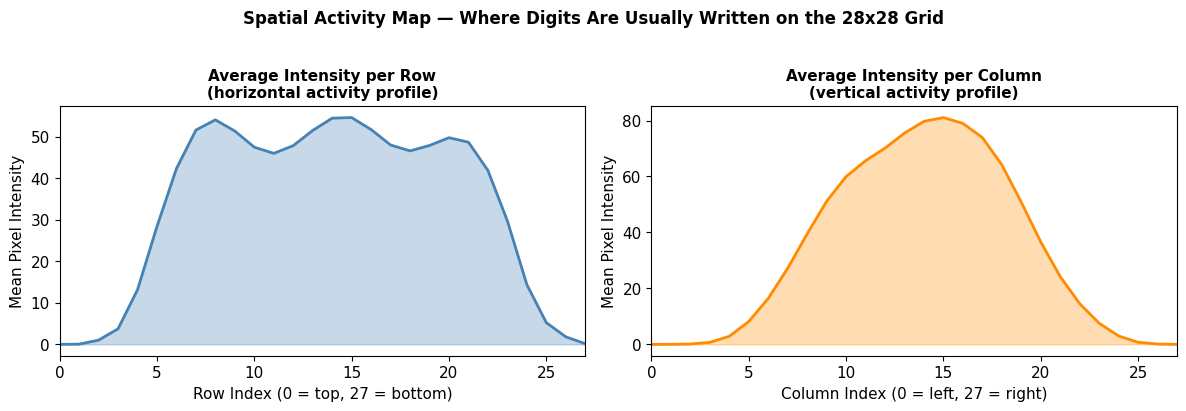

FINDING:
  - Most active row    : row 15 (digits are written in the vertical center)
  - Most active column : col 15 (digits are horizontally centered)
  - Border rows/cols (0–3 and 24–27) show near-zero activity — pure margin/padding.
  => Digits are well-centered on the canvas — no cropping or alignment preprocessing needed.


In [14]:
# Average intensity per row and per column across all training images
# axis=0 collapses the image dimension (60000 images)
# axis=(0,1) then collapses rows -> per-column profile
# axis=(0,2) then collapses columns -> per-row profile

mean_row = X_train_original.mean(axis=(0, 2))  # shape: (28,) — average across all images and columns
mean_col = X_train_original.mean(axis=(0, 1))  # shape: (28,) — average across all images and rows

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Row activity
axes[0].plot(range(28), mean_row, color='steelblue', linewidth=2)
axes[0].fill_between(range(28), mean_row, alpha=0.3, color='steelblue')
axes[0].set_title('Average Intensity per Row\n(horizontal activity profile)', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Row Index (0 = top, 27 = bottom)')
axes[0].set_ylabel('Mean Pixel Intensity')
axes[0].set_xlim(0, 27)

# Column activity
axes[1].plot(range(28), mean_col, color='darkorange', linewidth=2)
axes[1].fill_between(range(28), mean_col, alpha=0.3, color='darkorange')
axes[1].set_title('Average Intensity per Column\n(vertical activity profile)', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Column Index (0 = left, 27 = right)')
axes[1].set_ylabel('Mean Pixel Intensity')
axes[1].set_xlim(0, 27)

fig.suptitle('Spatial Activity Map — Where Digits Are Usually Written on the 28x28 Grid',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

most_active_row = np.argmax(mean_row)
most_active_col = np.argmax(mean_col)
print("FINDING:")
print(f"  - Most active row    : row {most_active_row} (digits are written in the vertical center)")
print(f"  - Most active column : col {most_active_col} (digits are horizontally centered)")
print(f"  - Border rows/cols (0–3 and 24–27) show near-zero activity — pure margin/padding.")
print(f"  => Digits are well-centered on the canvas — no cropping or alignment preprocessing needed.")

## 1.8 Normalization

In [15]:
# Apply normalization: cast to float32, then divide by 255
X_train = X_train.astype('float32') / 255.0
X_test  = X_test.astype('float32') / 255.0

print("Normalization complete!")
print()
print("BEFORE normalization:")
print(f"  Data type  : uint8")
print(f"  Value min  : {X_train_original.min()}")
print(f"  Value max  : {X_train_original.max()}")
print()
print("AFTER normalization:")
print(f"  Data type  : {X_train.dtype}")
print(f"  Value min  : {X_train.min():.4f}")
print(f"  Value max  : {X_train.max():.4f}")
print(f"  Mean       : {X_train.mean():.4f}")
print(f"  Std dev    : {X_train.std():.4f}")

Normalization complete!

BEFORE normalization:
  Data type  : uint8
  Value min  : 0
  Value max  : 255

AFTER normalization:
  Data type  : float32
  Value min  : 0.0000
  Value max  : 1.0000
  Mean       : 0.1307
  Std dev    : 0.3081


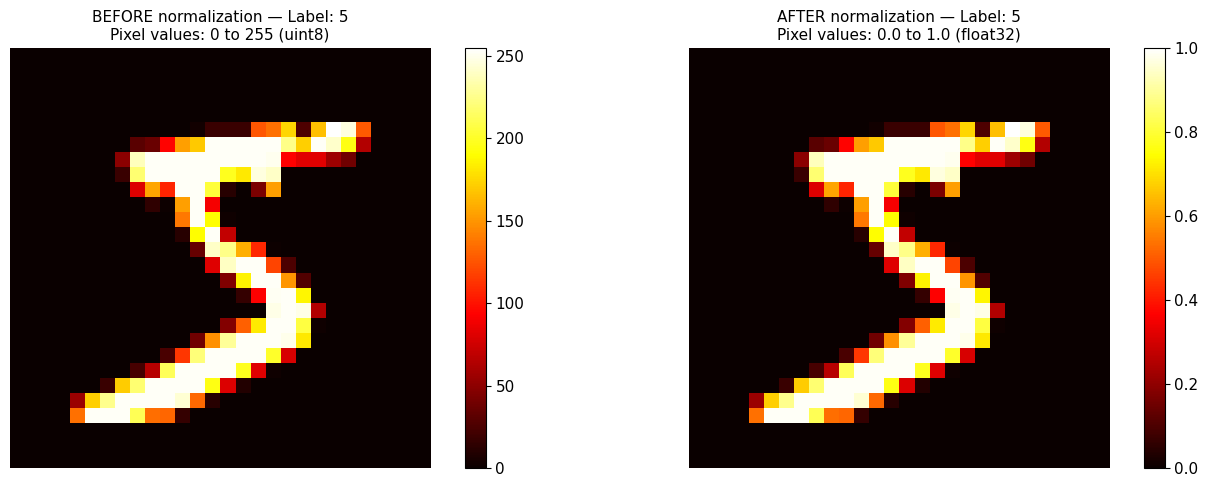

Note: Images look identical because normalization only rescales the numerical range.
      No visual information is changed — only the number scale is adjusted.

Sample normalized pixel values (rows 10–17, cols 10–17 — stroke region):
0.004 0.604 0.992 0.353 0.000 0.000 0.000 
0.000 0.545 0.992 0.745 0.008 0.000 0.000 
0.000 0.043 0.745 0.992 0.275 0.000 0.000 
0.000 0.000 0.137 0.945 0.882 0.627 0.424 
0.000 0.000 0.000 0.318 0.941 0.992 0.992 
0.000 0.000 0.000 0.000 0.176 0.729 0.992 
0.000 0.000 0.000 0.000 0.000 0.063 0.365 


In [16]:
# Visual comparison: before vs after normalization

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

im1 = axes[0].imshow(X_train_original[0], cmap='hot')
axes[0].set_title(f'BEFORE normalization — Label: {y_train[0]}\nPixel values: 0 to 255 (uint8)', fontsize=11)
axes[0].axis('off')
plt.colorbar(im1, ax=axes[0])

im2 = axes[1].imshow(X_train[0], cmap='hot')
axes[1].set_title(f'AFTER normalization — Label: {y_train[0]}\nPixel values: 0.0 to 1.0 (float32)', fontsize=11)
axes[1].axis('off')
plt.colorbar(im2, ax=axes[1])

plt.tight_layout()
plt.show()
print("Note: Images look identical because normalization only rescales the numerical range.")
print("      No visual information is changed — only the number scale is adjusted.")

# Show sample normalized pixel values (rows 10–17, cols 10–17 — where stroke is)
print()
print("Sample normalized pixel values (rows 10–17, cols 10–17 — stroke region):")
for row in X_train[0][10:17]:
    for pixel in row[10:17]:
        print("{:0.3f}".format(pixel), end=" ")
    print()

## 1.9 Reshape & Flatten

In [17]:
print("BEFORE reshape/flatten:")
print(f"  X_train shape: {X_train.shape}")
print(f"  X_test shape : {X_test.shape}")
print()

# --- For CNN ---
# Add channel dimension: (N, 28, 28) -> (N, 28, 28, 1)
X_train_cnn = X_train.reshape(X_train.shape[0], 28, 28, 1)
X_test_cnn  = X_test.reshape(X_test.shape[0], 28, 28, 1)

# --- For traditional ML (KNN, SVM, Random Forest) ---
# Flatten: (N, 28, 28) -> (N, 784)
# Using -1 lets numpy auto-calculate the second dimension (28*28 = 784)
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat  = X_test.reshape(X_test.shape[0], -1)

print("AFTER reshape/flatten:")
print("-" * 58)
print(f"  {'Format':<28} {'Train shape':<18} {'Test shape'}")
print("-" * 58)
print(f"  {'CNN — 4D tensor':<28} {str(X_train_cnn.shape):<18} {str(X_test_cnn.shape)}")
print(f"  {'ML models — 2D matrix':<28} {str(X_train_flat.shape):<18} {str(X_test_flat.shape)}")
print("-" * 58)
print()
print(f"Verification: 28 x 28 x 1 = {28*28*1} features — matches dim 2 of X_train_flat")
print(f"Normalization preserved: X_train_flat min={X_train_flat.min():.1f}, max={X_train_flat.max():.1f}")

BEFORE reshape/flatten:
  X_train shape: (60000, 28, 28)
  X_test shape : (10000, 28, 28)

AFTER reshape/flatten:
----------------------------------------------------------
  Format                       Train shape        Test shape
----------------------------------------------------------
  CNN — 4D tensor              (60000, 28, 28, 1) (10000, 28, 28, 1)
  ML models — 2D matrix        (60000, 784)       (10000, 784)
----------------------------------------------------------

Verification: 28 x 28 x 1 = 784 features — matches dim 2 of X_train_flat
Normalization preserved: X_train_flat min=0.0, max=1.0


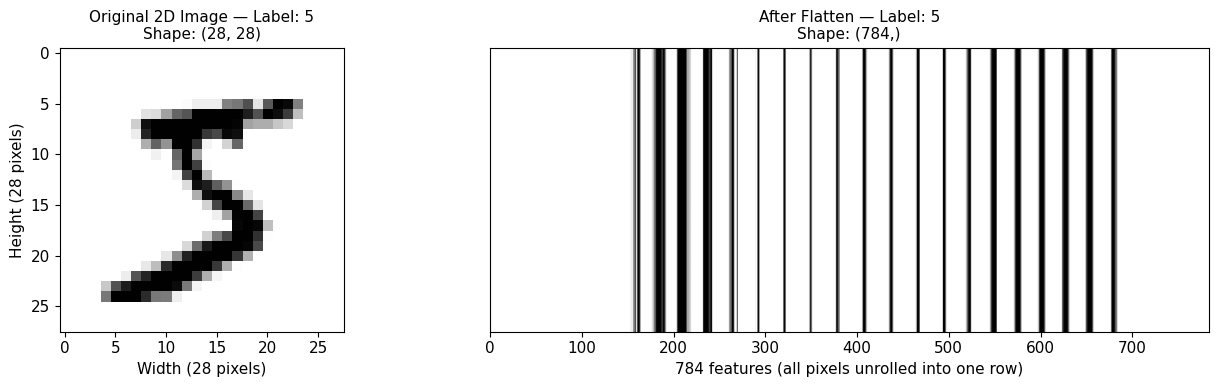

Note: Image information is fully preserved — only the data organization changes.
      KNN, SVM, and Random Forest will receive X_train_flat and X_test_flat as input.


In [18]:
# Visual illustration: original 2D image vs flattened 1D vector

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Original 2D image
axes[0].imshow(X_train[0].reshape(28, 28), cmap='binary')
axes[0].set_title(f'Original 2D Image — Label: {y_train[0]}\nShape: (28, 28)', fontsize=11)
axes[0].set_xlabel('Width (28 pixels)')
axes[0].set_ylabel('Height (28 pixels)')

# Flattened 1D vector shown as a single-row heatmap
axes[1].imshow(X_train_flat[0].reshape(1, 784), cmap='binary', aspect='auto')
axes[1].set_title(f'After Flatten — Label: {y_train[0]}\nShape: (784,)', fontsize=11)
axes[1].set_xlabel('784 features (all pixels unrolled into one row)')
axes[1].set_yticks([])

plt.tight_layout()
plt.show()

print("Note: Image information is fully preserved — only the data organization changes.")
print("      KNN, SVM, and Random Forest will receive X_train_flat and X_test_flat as input.")

**Data flow summary:**

```
Raw data: uint8, values 0–255, shape (N, 28, 28)
                    |
              Normalization
           float32, values 0.0–1.0
                    |
          __________|__________
         |                     |
       Reshape               Flatten
    (N, 28, 28, 1)           (N, 784)
         |                     |
        CNN             KNN / SVM / Random Forest

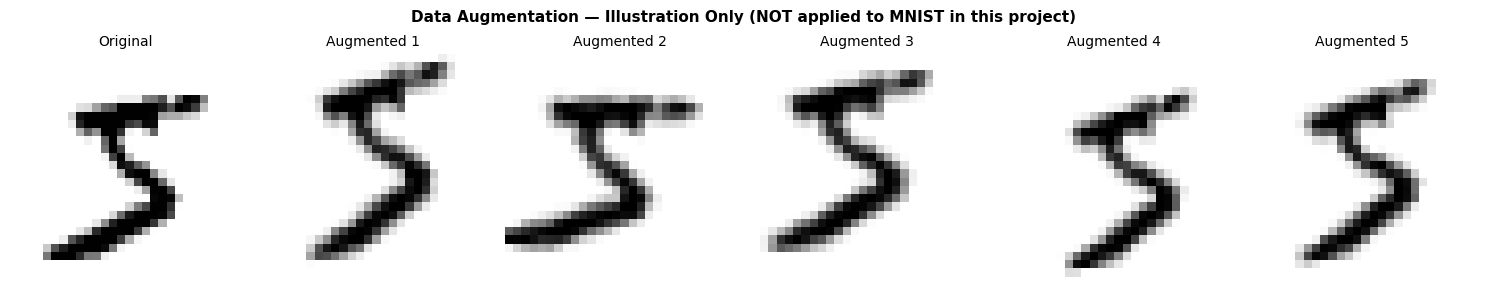

Conclusion: Augmentation is NOT applied.
  Reason: MNIST is already large, balanced, and achieves high accuracy without it.


In [19]:
# ILLUSTRATION ONLY — Data Augmentation is NOT applied to the actual training data

datagen_demo = ImageDataGenerator(
    rotation_range=10,       # Rotate image by up to ±10 degrees
    zoom_range=0.1,          # Zoom in/out by up to 10%
    width_shift_range=0.1,   # Shift horizontally by up to 10%
    height_shift_range=0.1   # Shift vertically by up to 10%
)

sample_img = X_train_cnn[0].reshape(1, 28, 28, 1)

fig, axes = plt.subplots(1, 6, figsize=(15, 3))
axes[0].imshow(X_train_cnn[0].reshape(28, 28), cmap='binary')
axes[0].set_title('Original', fontsize=10)
axes[0].axis('off')

gen = datagen_demo.flow(sample_img, batch_size=1)
for i in range(1, 6):
    aug_img = next(gen)[0].reshape(28, 28)
    axes[i].imshow(aug_img, cmap='binary')
    axes[i].set_title(f'Augmented {i}', fontsize=10)
    axes[i].axis('off')

fig.suptitle('Data Augmentation — Illustration Only (NOT applied to MNIST in this project)',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

print("Conclusion: Augmentation is NOT applied.")
print("  Reason: MNIST is already large, balanced, and achieves high accuracy without it.")

## 1.10 Phase Summary

In [20]:
print("[1] DATASET")
print(f"    Source         : MNIST (keras.datasets.mnist)")
print(f"    Training set   : {X_train_cnn.shape[0]:,} images")
print(f"    Test set       : {X_test_cnn.shape[0]:,} images")
print(f"    Image size     : 28 x 28 pixels, grayscale")
print(f"    Classes        : 10 (digits 0–9)")
print()
print("[2] EDA FINDINGS")
print(f"    Class balance  : BALANCED (~6,000 samples per class)")
print(f"    Avg sparsity   : ~{(X_train_original==0).mean()*100:.0f}% background pixels per image")
print(f"    Spatial layout : Digits centered; border rows/cols are inactive margins")
print(f"    Intra-class    : Visible variation in stroke style — model must generalize")
print()
print("[3] PREPROCESSING APPLIED")
print(f"    Normalization  : ÷ 255.0  =>  pixel values in [0.0, 1.0]")
print(f"    Data type      : uint8  =>  float32")
print(f"    Reshape (CNN)  : (N,28,28)  =>  (N,28,28,1)  [add channel dim]")
print(f"    Flatten (ML)   : (N,28,28)  =>  (N,784)      [unroll to vector]")
print(f"    Augmentation   : NOT applied (dataset is already large and balanced)")
print()
print("[4] OUTPUT VARIABLES FOR PHASE II")
print(f"    --- For CNN (TensorFlow/Keras) ---")
print(f"    X_train_cnn  : shape={X_train_cnn.shape},  dtype={X_train_cnn.dtype}")
print(f"    X_test_cnn   : shape={X_test_cnn.shape},   dtype={X_test_cnn.dtype}")
print(f"    --- For KNN / SVM / Random Forest (sklearn) ---")
print(f"    X_train_flat : shape={X_train_flat.shape}, dtype={X_train_flat.dtype}")
print(f"    X_test_flat  : shape={X_test_flat.shape},  dtype={X_test_flat.dtype}")
print(f"    --- Labels (shared across all models) ---")
print(f"    y_train      : shape={y_train.shape}")
print(f"    y_test       : shape={y_test.shape}")

[1] DATASET
    Source         : MNIST (keras.datasets.mnist)
    Training set   : 60,000 images
    Test set       : 10,000 images
    Image size     : 28 x 28 pixels, grayscale
    Classes        : 10 (digits 0–9)

[2] EDA FINDINGS
    Class balance  : BALANCED (~6,000 samples per class)
    Avg sparsity   : ~81% background pixels per image
    Spatial layout : Digits centered; border rows/cols are inactive margins
    Intra-class    : Visible variation in stroke style — model must generalize

[3] PREPROCESSING APPLIED
    Normalization  : ÷ 255.0  =>  pixel values in [0.0, 1.0]
    Data type      : uint8  =>  float32
    Reshape (CNN)  : (N,28,28)  =>  (N,28,28,1)  [add channel dim]
    Flatten (ML)   : (N,28,28)  =>  (N,784)      [unroll to vector]
    Augmentation   : NOT applied (dataset is already large and balanced)

[4] OUTPUT VARIABLES FOR PHASE II
    --- For CNN (TensorFlow/Keras) ---
    X_train_cnn  : shape=(60000, 28, 28, 1),  dtype=float32
    X_test_cnn   : shape=(1000

# 2. Machine Learning Models

## 2.1 PCA for Speeding up SVM and Learning Curves

In [21]:
from sklearn.model_selection import learning_curve

def plot_learning_curve(estimator, title, X, y, cv=3):
    plt.figure(figsize=(10, 6))
    plt.title(title)
    plt.xlabel("Training examples")
    plt.ylabel("Score")

    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=cv, n_jobs=-1,
        train_sizes=np.linspace(.1, 1.0, 5), scoring='accuracy'
    )

    train_scores_mean = np.mean(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)

    plt.grid()
    plt.plot(train_sizes, train_scores_mean, 'o-', color="r", label="Training score")
    plt.plot(train_sizes, test_scores_mean, 'o-', color="g", label="Cross-validation score")
    plt.legend(loc="best")
    plt.show()

## 2.2 KNN

In [22]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, f1_score
import time

# Setting up
N_TRAIN = 60000
X_knn_train = X_train_flat[:N_TRAIN]
y_knn_train = y_train[:N_TRAIN]

# Train
knn = KNeighborsClassifier(n_neighbors=3, n_jobs=-1)
t0 = time.time()
knn.fit(X_knn_train, y_knn_train)
train_time = time.time() - t0

# Evaluate
t0 = time.time()
y_pred_knn = knn.predict(X_test_flat)
infer_time = time.time() - t0

acc = accuracy_score(y_test, y_pred_knn)
f1  = f1_score(y_test, y_pred_knn, average='weighted')

print(f"KNN Accuracy: {acc:.4f}")
print(f"KNN F1 Score: {f1:.4f}")
print(f"Train time  : {train_time:.2f}s")
print(f"Infer time  : {infer_time:.2f}s")

KNN Accuracy: 0.9705
KNN F1 Score: 0.9705
Train time  : 0.03s
Infer time  : 36.31s


## 2.3 SVM

In [23]:
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, f1_score
import time

# SVM với Regularization chặt hơn (C=0.5)
svm_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(kernel='rbf', C=0.5, gamma='scale', random_state=42))
])

N_TRAIN = 60000
X_svm_train = X_train_flat[:N_TRAIN]
y_svm_train = y_train[:N_TRAIN]

# Train
t0 = time.time()
svm_pipeline.fit(X_svm_train, y_svm_train)
train_time = time.time() - t0

# Evaluate
t0 = time.time()
y_pred_svm = svm_pipeline.predict(X_test_flat)
infer_time = time.time() - t0

acc_svm = accuracy_score(y_test, y_pred_svm)
f1_svm  = f1_score(y_test, y_pred_svm, average='weighted')

print(f"SVM Accuracy : {acc_svm:.4f}")
print(f"SVM F1 Score : {f1_svm:.4f}")
print(f"Train time   : {train_time:.2f}s")
print(f"Infer time   : {infer_time:.2f}s")

SVM Accuracy : 0.9596
SVM F1 Score : 0.9596
Train time   : 455.98s
Infer time   : 143.06s


## 2.4 Random Forest

In [24]:
from sklearn.ensemble import RandomForestClassifier
import time

# RF config
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

N_TRAIN = 60000
X_rf_train = X_train_flat[:N_TRAIN]
y_rf_train = y_train[:N_TRAIN]

# Train
t0 = time.time()
rf.fit(X_rf_train, y_rf_train)
train_time = time.time() - t0

# Evaluate
t0 = time.time()
y_pred_rf = rf.predict(X_test_flat)
infer_time = time.time() - t0

acc_rf = accuracy_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf, average='weighted')

print(f"RF Accuracy : {acc_rf:.4f}")
print(f"RF F1 Score : {f1_rf:.4f}")
print(f"Train time  : {train_time:.2f}s")
print(f"Infer time  : {infer_time:.2f}s")

RF Accuracy : 0.9477
RF F1 Score : 0.9477
Train time  : 21.58s
Infer time  : 0.18s


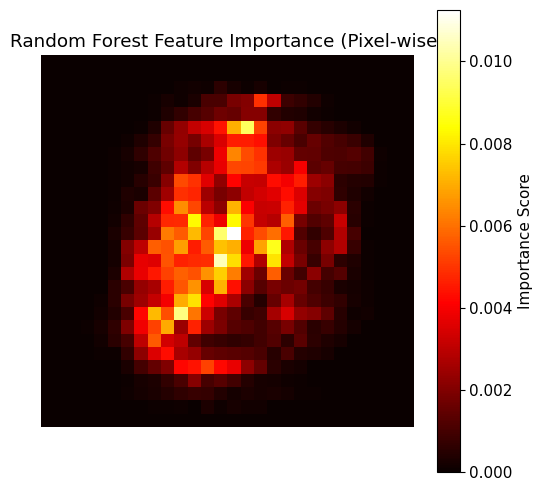

Saved: rf_feature_importance.png


In [25]:
importances = rf.feature_importances_
importances_img = importances.reshape(28, 28)

plt.figure(figsize=(6, 6))
plt.imshow(importances_img, cmap='hot')
plt.title("Random Forest Feature Importance (Pixel-wise)")
plt.colorbar(label='Importance Score')
plt.axis('off')

# Lưu ảnh Feature Importance
plt.savefig("rf_feature_importance.png")
plt.show()
print("Saved: rf_feature_importance.png")

## 2.5 Comparison

### 2.5.1 Confusion Matrix

,Accuracy,F1 Score (Weighted)
KNN,0.9705,0.970452
SVM,0.9596,0.959619
RF,0.9477,0.947686


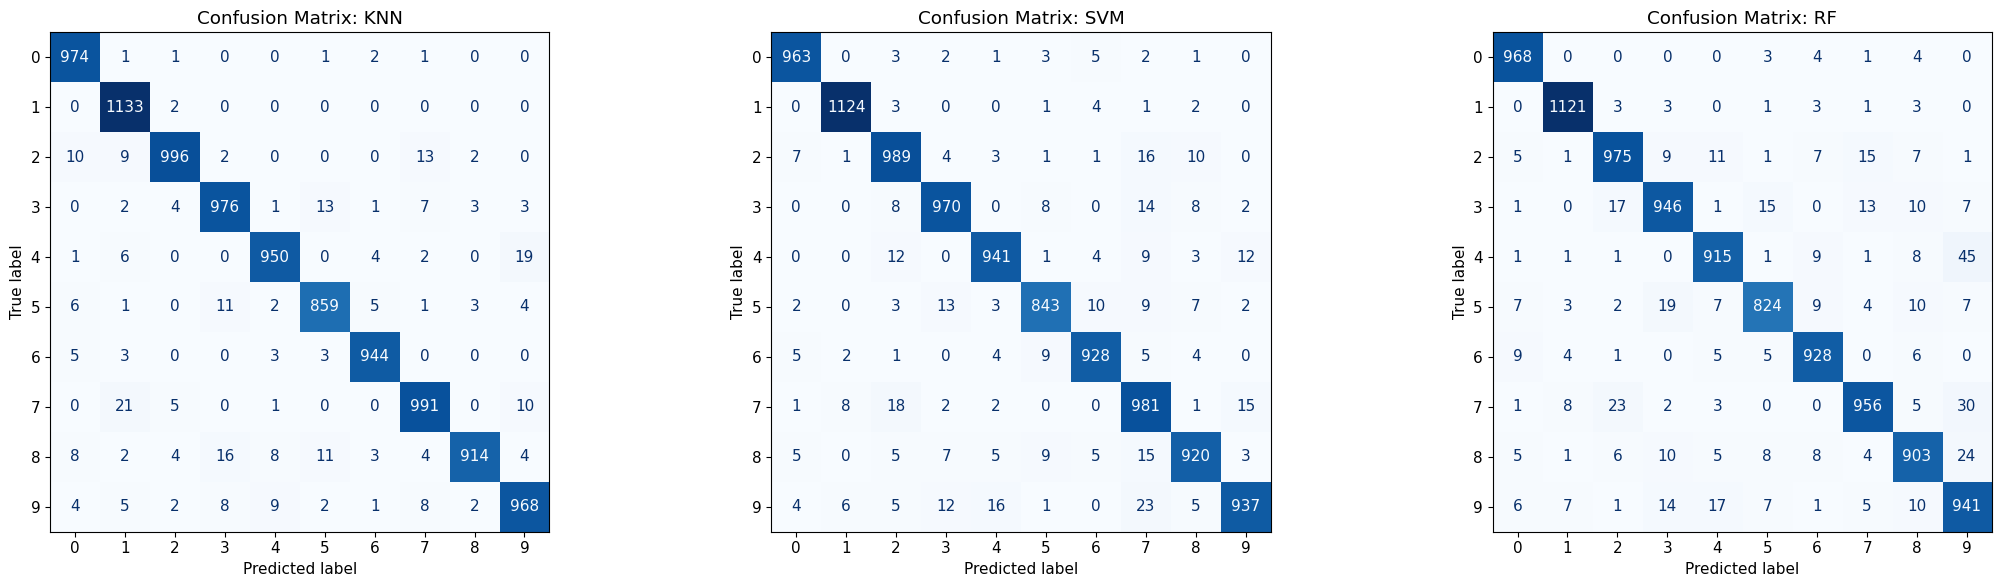

In [26]:
import pandas as pd
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, f1_score
import matplotlib.pyplot as plt

# Kết quả
final_results = {
    "KNN":      {"acc": accuracy_score(y_test, y_pred_knn),
                 "f1":  f1_score(y_test, y_pred_knn, average='weighted'),
                 "y_pred": y_pred_knn},
    "SVM":      {"acc": accuracy_score(y_test, y_pred_svm),
                  "f1":  f1_score(y_test, y_pred_svm, average='weighted'),
                  "y_pred": y_pred_svm},
    "RF" :      {"acc": accuracy_score(y_test, y_pred_rf),
                  "f1":  f1_score(y_test, y_pred_rf, average='weighted'),
                  "y_pred": y_pred_rf},
}

# Hiển thị bảng so sánh
df_compare = pd.DataFrame(final_results).T[['acc', 'f1']]
df_compare.columns = ['Accuracy', 'F1 Score (Weighted)']
display(df_compare)

# Vẽ Confusion Matrix so sánh giữa 3 mô hình
fig, axes = plt.subplots(1, 3, figsize=(22, 6))
for i, (name, m) in enumerate(final_results.items()):
    cm = confusion_matrix(y_test, m['y_pred'])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=range(10))
    disp.plot(ax=axes[i], cmap='Blues', colorbar=False)
    axes[i].set_title(f"Confusion Matrix: {name}")

plt.tight_layout()
plt.show()

### 2.5.2 Learning Curves

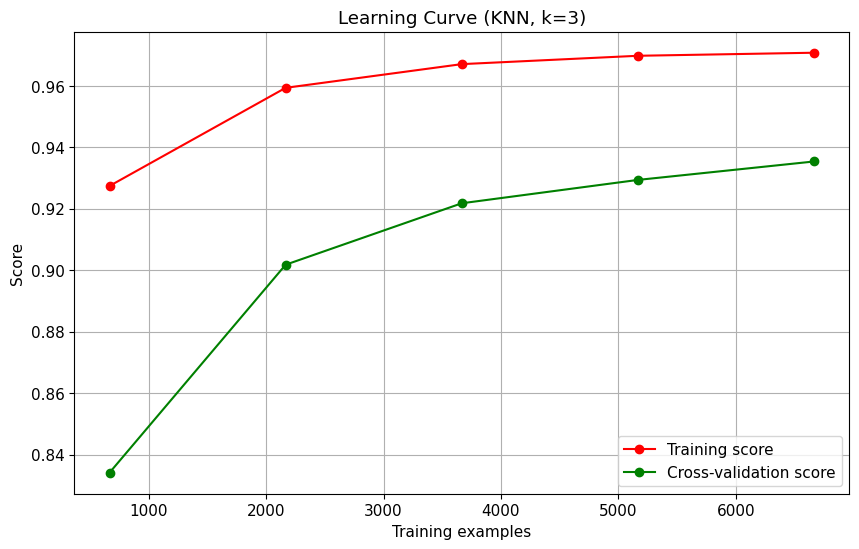

In [27]:
# Sử dụng tập con 10,000 mẫu để vẽ cho nhanh
SUBSET_SIZE = 10000
X_lc = X_train_flat[:SUBSET_SIZE]
y_lc = y_train[:SUBSET_SIZE]

# 1. Learning Curve cho KNN
plot_learning_curve(knn, "Learning Curve (KNN, k=3)", X_lc, y_lc)

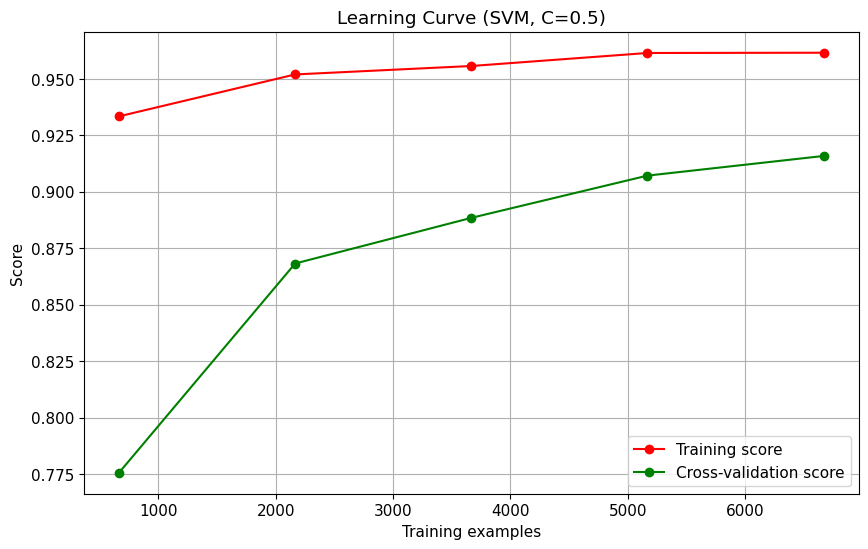

In [28]:
# 2. Learning Curve cho SVM (Đã giảm C=0.5 để bớt Overfit)
svm_regularized = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(kernel='rbf', C=0.5, gamma='scale', random_state=42))
])

plot_learning_curve(svm_regularized, "Learning Curve (SVM, C=0.5)", X_lc, y_lc)

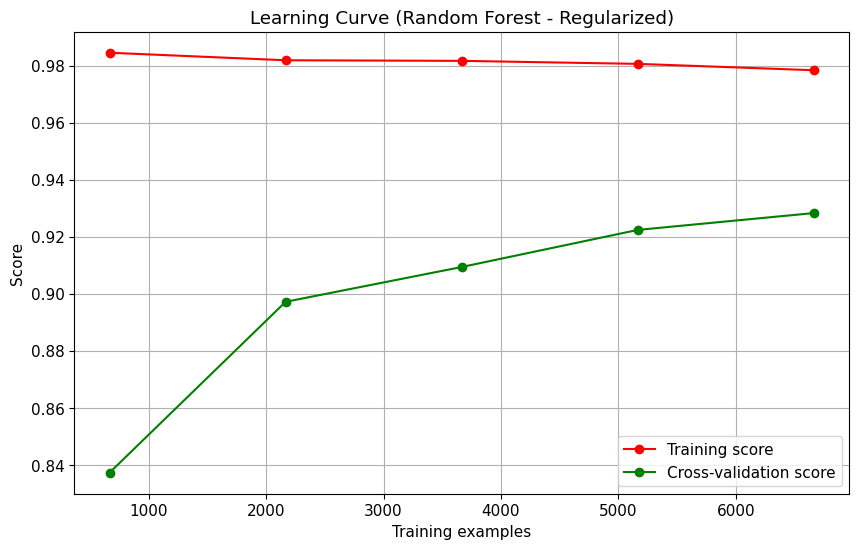

In [29]:
# 3. Learning Curve cho RF
rf_regularized = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

plot_learning_curve(rf_regularized, "Learning Curve (Random Forest - Regularized)", X_lc, y_lc)

# 3. Deep Learning Models

## 3.1 MLP - Multilayer Perceptron

### 3.1.1 Model Training

In [30]:
def build_pure_mlp():
    model = models.Sequential([
        layers.Input(shape=(784,), name="mlp_input"),
        layers.Dense(128, activation='relu', name="mlp_hidden_layer"),
        layers.Dense(10, activation='softmax', name="mlp_output_layer")
    ], name="Baseline_MLP_Rebuilt")

    model.compile(
        optimizer=optimizers.Adam(learning_rate=0.001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

mlp_model = build_pure_mlp()
mlp_model.summary()

Model: "Baseline_MLP_Rebuilt"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mlp_hidden_layer (Dense)        │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mlp_output_layer (Dense)        │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

In [31]:
history_mlp = mlp_model.fit(
    X_train_flat, y_train,
    epochs=15,
    batch_size=64,
    validation_split=0.1,
    verbose=1
)

Epoch 1/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.9107 - loss: 0.3201 - val_accuracy: 0.9595 - val_loss: 0.1447
Epoch 2/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9579 - loss: 0.1451 - val_accuracy: 0.9702 - val_loss: 0.1062
Epoch 3/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9701 - loss: 0.1027 - val_accuracy: 0.9717 - val_loss: 0.0930
Epoch 4/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9772 - loss: 0.0780 - val_accuracy: 0.9733 - val_loss: 0.0862
Epoch 5/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9825 - loss: 0.0612 - val_accuracy: 0.9742 - val_loss: 0.0845
Epoch 6/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9862 - loss: 0.0491 - val_accuracy: 0.9742 - val_loss: 0.0855
Epoch 7/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9895 - loss: 0.0395 - val_accuracy: 0.9742 - val_loss: 0.0869
Epoch 8/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9920 - loss: 0.0315 - val_accuracy: 0.

### 3.1.2 Visualization

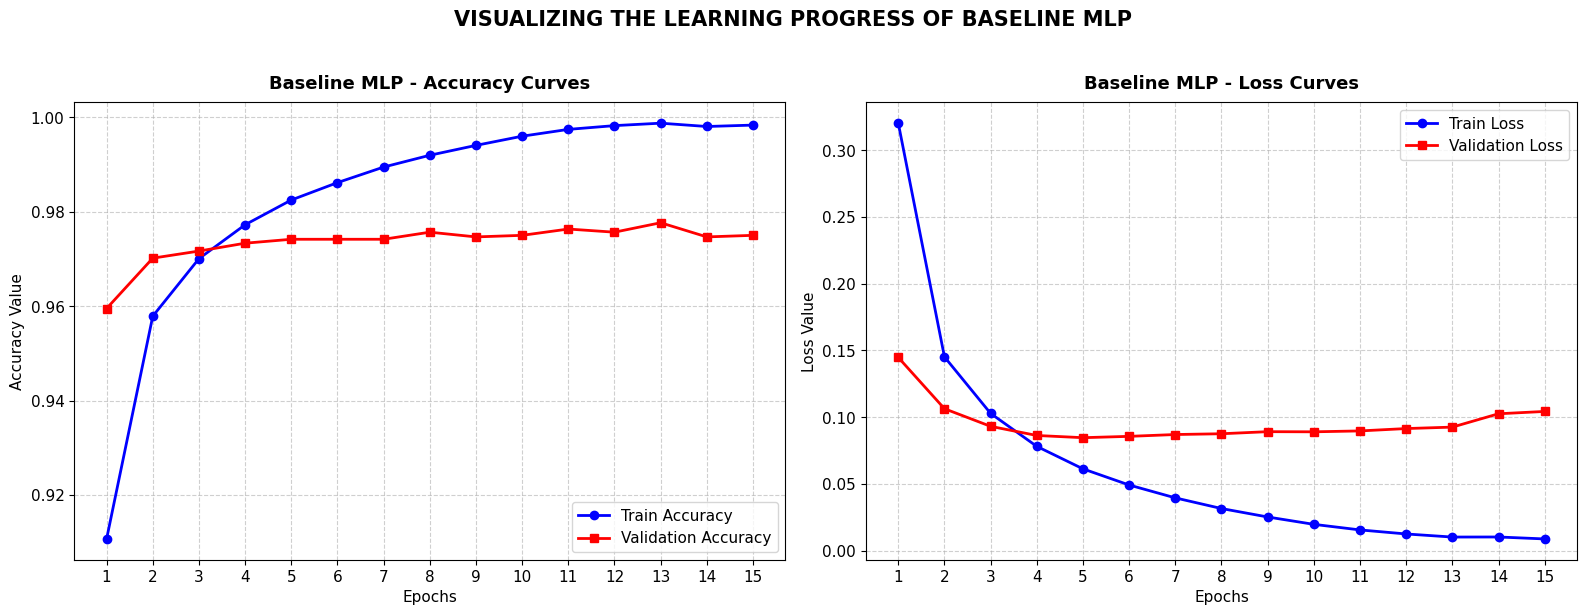

In [32]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
epochs_range = range(1, len(history_mlp.history['accuracy']) + 1)

# Accuracy graph
ax1.plot(epochs_range, history_mlp.history['accuracy'], 'b-o', label='Train Accuracy', linewidth=2)
ax1.plot(epochs_range, history_mlp.history['val_accuracy'], 'r-s', label='Validation Accuracy', linewidth=2)
ax1.set_title('Baseline MLP - Accuracy Curves', fontsize=13, fontweight='bold', pad=10)
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Accuracy Value')
ax1.set_xticks(epochs_range)
ax1.grid(True, linestyle='--', alpha=0.6)
ax1.legend(loc='lower right')

# Loss graph
ax2.plot(epochs_range, history_mlp.history['loss'], 'b-o', label='Train Loss', linewidth=2)
ax2.plot(epochs_range, history_mlp.history['val_loss'], 'r-s', label='Validation Loss', linewidth=2)
ax2.set_title('Baseline MLP - Loss Curves', fontsize=13, fontweight='bold', pad=10)
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Loss Value')
ax2.set_xticks(epochs_range)
ax2.grid(True, linestyle='--', alpha=0.6)
ax2.legend(loc='upper right')

plt.suptitle("VISUALIZING THE LEARNING PROGRESS OF BASELINE MLP", fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

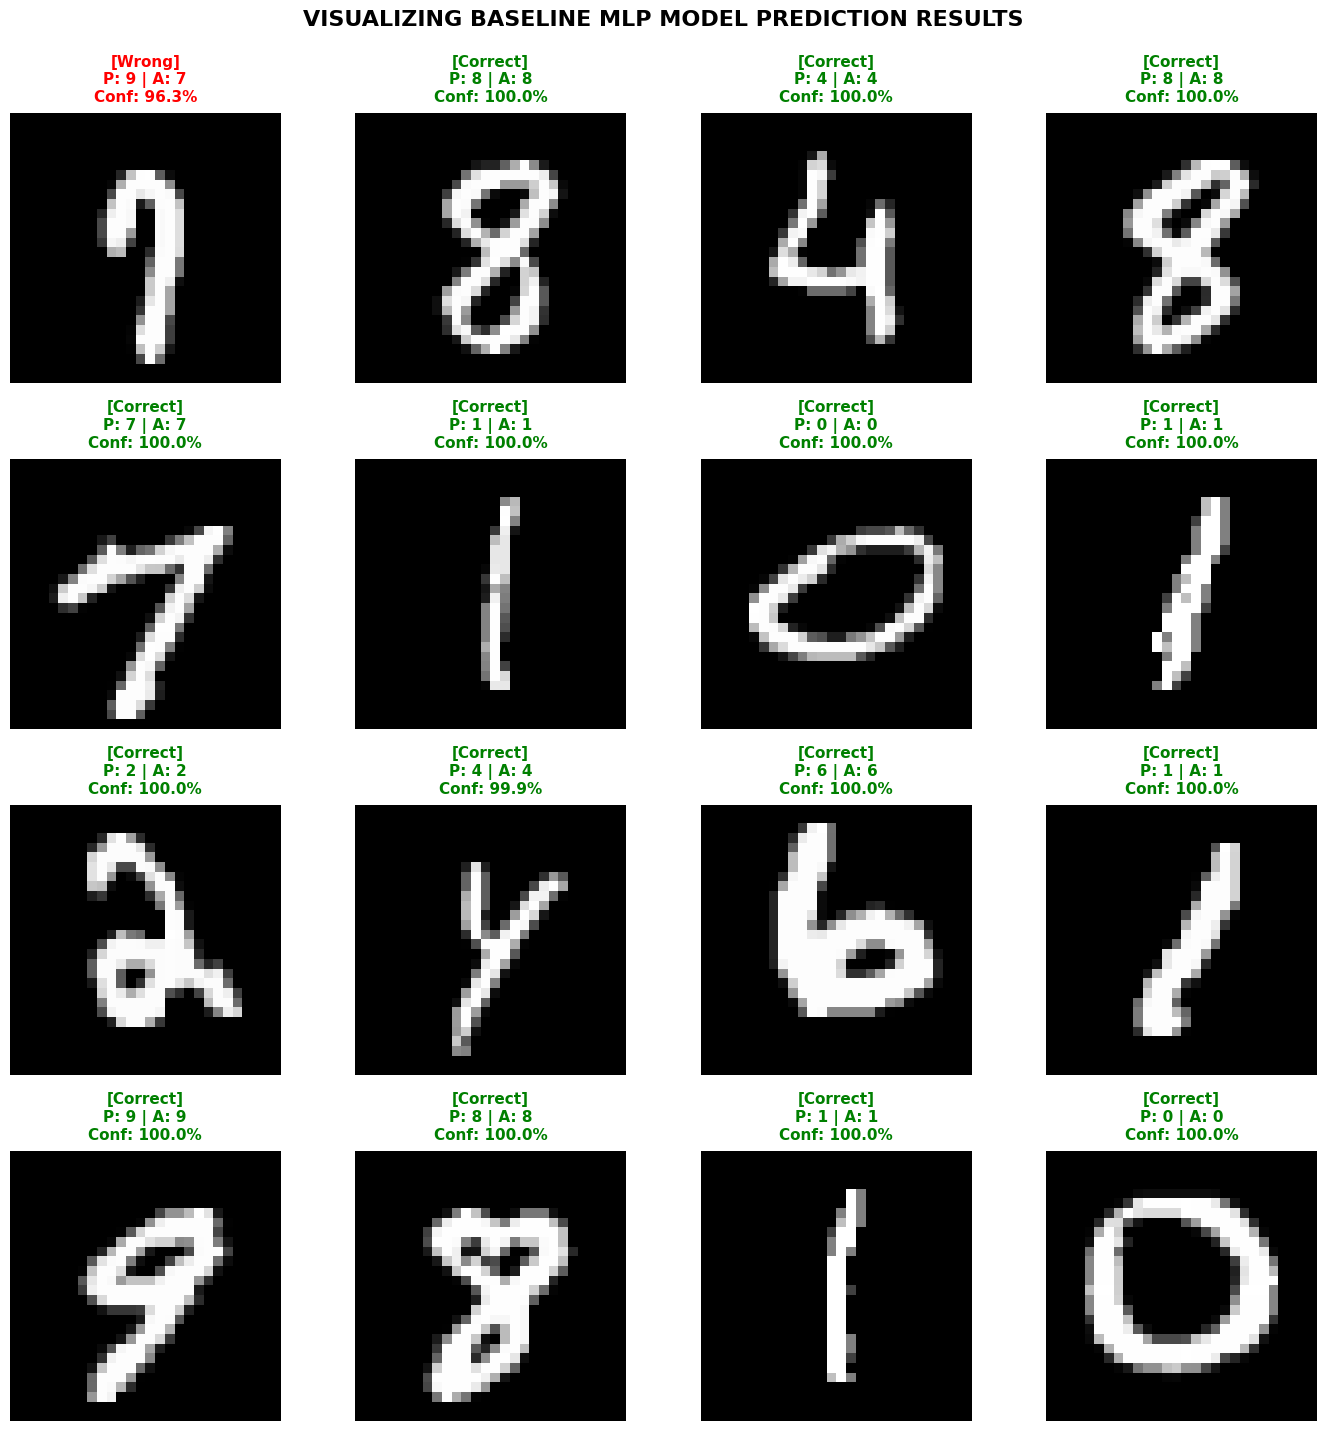

In [33]:
def plot_predictions_mlp(X_test_flat_images, y_true, y_pred, y_probs, num_rows=4, num_cols=4):

    total_images = len(X_test_flat_images)
    random_indices = np.random.choice(total_images, size=(num_rows * num_cols), replace=False)

    fig, axes = plt.subplots(nrows=num_rows, ncols=num_cols, figsize=(14, 14))
    axes = axes.ravel()

    for i, idx in enumerate(random_indices):
        #Restore the 784 vector to a 2D 28x28 matrix to display the original grayscale image
        img = X_test_flat_images[idx].reshape(28, 28)
        actual_label = y_true[idx]
        predicted_label = y_pred[idx]

        # Get the maximum confident probability
        confidence = np.max(y_probs[idx]) * 100

        axes[i].imshow(img, cmap='gray')
        axes[i].axis('off')

        # Dynamic title color change logic
        if predicted_label == actual_label:
            title_color = 'green'
            status_text = "Correct"
        else:
            title_color = 'red'
            status_text = "Wrong"

        title_string = f"[{status_text}]\nP: {predicted_label} | A: {actual_label}\nConf: {confidence:.1f}%"
        axes[i].set_title(title_string, color=title_color, fontsize=11, fontweight='bold', pad=8)

    plt.tight_layout()
    plt.suptitle("VISUALIZING BASELINE MLP MODEL PREDICTION RESULTS", fontsize=16, fontweight='bold', y=1.02)
    plt.show()

y_pred_probs_mlp = mlp_model.predict(X_test_flat, verbose=0)
y_pred_mlp = np.argmax(y_pred_probs_mlp, axis=1)


plot_predictions_mlp(X_test_flat, y_test, y_pred_mlp, y_pred_probs_mlp)

mlp_model.save('baseline_mnist_mlp.keras')


### 3.1.3 Parameter Tuning with Optuna

In [36]:
from sklearn.model_selection import train_test_split

(X_train_raw2, y_train_raw2), (X_test_raw2, y_test_raw2) = tf.keras.datasets.mnist.load_data()

X_all2 = np.concatenate((X_train_raw2, X_test_raw2), axis=0)
y_all2 = np.concatenate((y_train_raw2, y_test_raw2), axis=0)

X_all_norm2 = X_all2.astype('float32') / 255.0

X_train_val_raw2, X_test_raw_final2, y_train_val2, y_test2 = train_test_split(
    X_all_norm2, y_all2, test_size=0.10, random_state=42, stratify=y_all2
)

X_train_raw_final2, X_val_raw_final2, y_train2, y_val2 = train_test_split(
    X_train_val_raw2, y_train_val2, test_size=(1/9), random_state=42, stratify=y_train_val2
)


X_train_flat2 = X_train_raw_final2.reshape(-1, 784)
X_val_flat2 = X_val_raw_final2.reshape(-1, 784)
X_test_flat2 = X_test_raw_final2.reshape(-1, 784)

X_train_cnn2 = X_train_raw_final2.reshape(-1, 28, 28, 1)
X_val_cnn2 = X_val_raw_final2.reshape(-1, 28, 28, 1)
X_test_cnn2 = X_test_raw_final2.reshape(-1, 28, 28, 1)

In [37]:
import optuna
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers

def objective_mlp(trial):
    """
    Optuna objective function for tuning MLP hyperparameters.
    Perfectly synchronized with the CNN's structural design and search space.
    """
    # 1. Hyperparameter search space (Identical to your CNN setup)
    lr = trial.suggest_float('learning_rate', 1e-4, 1e-2, log=True)
    num_units_1 = trial.suggest_categorical('num_filters', [32, 64]) # Mapping filter count to hidden units
    dropout_rate = trial.suggest_float('dropout_rate', 0.2, 0.5)
    b_size = trial.suggest_categorical('batch_size', [32, 64, 128])

    # 2. Model Architecture - Synchronized with Batch Normalization
    model = models.Sequential([
        layers.Input(shape=(784,), name="mlp_input_layer"),

        # MLP Block 1 (Mirrors Conv Block 1)
        layers.Dense(units=num_units_1),
        layers.BatchNormalization(),
        layers.Activation('relu'),

        # MLP Block 2 (Mirrors Conv Block 2 & Fully Connected Layer)
        layers.Dense(units=128),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Dropout(rate=dropout_rate),

        # Output Layer
        layers.Dense(10, activation='softmax', name="mlp_output_layer")
    ], name="Baseline_MLP_Synchronized")

    # 3. Compile Model with matching Adam configuration
    model.compile(
        optimizer=optimizers.Adam(learning_rate=lr),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    # 4. Train Model using your 3-split validation set (or validation_split=0.1)
    history = model.fit(
        X_train_flat2, y_train2,
        epochs=3,
        batch_size=b_size,
        validation_data=(X_val_flat2, y_val2), # Clean split to prevent test data leakage
        verbose=0
    )

    return max(history.history['val_accuracy'])

# --- Initialize and Execute Optuna Study for MLP ---
study_mlp = optuna.create_study(direction='maximize')
print("--- Starting Hyperparameter Optimization for MLP with Optuna (5 Trials) ---")
study_mlp.optimize(objective_mlp, n_trials=5)

# Print optimization results
print("\nOPTUNA MLP OPTIMIZATION RESULTS ")
print(f"Best MLP Validation Accuracy: {study_mlp.best_value:.4f}")
print("Best MLP Hyperparameters:")
for key, value in study_mlp.best_params.items():
    print(f"  - {key}: {value}")

[I 2026-06-18 16:36:49,312] A new study created in memory with name: no-name-e2b42f02-8d7a-4b2e-93ca-cb0446494b94


--- Starting Hyperparameter Optimization for MLP with Optuna (5 Trials) ---


[I 2026-06-18 16:37:03,463] Trial 0 finished with value: 0.9161428809165955 and parameters: {'learning_rate': 0.00010587630136965346, 'num_filters': 32, 'dropout_rate': 0.2518999182357951, 'batch_size': 128}. Best is trial 0 with value: 0.9161428809165955.
[I 2026-06-18 16:37:18,762] Trial 1 finished with value: 0.9425714015960693 and parameters: {'learning_rate': 0.0002049737032990471, 'num_filters': 64, 'dropout_rate': 0.3795337863516423, 'batch_size': 128}. Best is trial 1 with value: 0.9425714015960693.
[I 2026-06-18 16:37:29,371] Trial 2 finished with value: 0.9661428332328796 and parameters: {'learning_rate': 0.005072301828361141, 'num_filters': 64, 'dropout_rate': 0.25233124007660396, 'batch_size': 128}. Best is trial 2 with value: 0.9661428332328796.
[I 2026-06-18 16:37:40,067] Trial 3 finished with value: 0.9085714221000671 and parameters: {'learning_rate': 0.00011061250123643737, 'num_filters': 32, 'dropout_rate': 0.3440831131901239, 'batch_size': 128}. Best is trial 2 with v


OPTUNA MLP OPTIMIZATION RESULTS 
Best MLP Validation Accuracy: 0.9700
Best MLP Hyperparameters:
  - learning_rate: 0.003579727981859057
  - num_filters: 64
  - dropout_rate: 0.23102297976699465
  - batch_size: 64


In [38]:
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers

# Retrieve best parameters from the Optuna study (assuming study_mlp has been run)
best_mlp_num_filters = study_mlp.best_params['num_filters'] # Corrected hyperparameter name
best_mlp_dropout = study_mlp.best_params['dropout_rate']
best_mlp_lr = study_mlp.best_params['learning_rate']
best_mlp_batch = study_mlp.best_params['batch_size']

# Recreate the model with the best hyperparameters and matching architecture
mlp_model_final = models.Sequential([
    layers.Input(shape=(784,), name="mlp_input_layer"),

    # MLP Block 1 (Mirrors Conv Block 1 from objective_mlp)
    layers.Dense(units=best_mlp_num_filters),
    layers.BatchNormalization(),
    layers.Activation('relu'),

    # MLP Block 2 (Mirrors Conv Block 2 & Fully Connected Layer from objective_mlp)
    layers.Dense(units=128),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dropout(rate=best_mlp_dropout),

    # Output Layer
    layers.Dense(10, activation='softmax', name="mlp_output_layer")
])

mlp_model_final.compile(
    optimizer=optimizers.Adam(learning_rate=best_mlp_lr),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_mlp_final = mlp_model_final.fit(
    X_train_flat2, y_train2,
    epochs=10,
    batch_size=best_mlp_batch,
    validation_data=(X_val_flat2, y_val2),
    verbose=1
)


--- Tiến hành huấn luyện Final MLP với 3 tập độc lập ---
Epoch 1/10
875/875 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9249 - loss: 0.2477 - val_accuracy: 0.9597 - val_loss: 0.1293
Epoch 2/10
875/875 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9607 - loss: 0.1270 - val_accuracy: 0.9659 - val_loss: 0.1160
Epoch 3/10
875/875 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9700 - loss: 0.0955 - val_accuracy: 0.9669 - val_loss: 0.1111
Epoch 4/10
875/875 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9749 - loss: 0.0787 - val_accuracy: 0.9716 - val_loss: 0.1108
Epoch 5/10
875/875 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9785 - loss: 0.0671 - val_accuracy: 0.9701 - val_loss: 0.1092
Epoch 6/10
875/875 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9826 - loss: 0.0533 - val_accuracy: 0.9707 - val_loss: 0.1110
Epoch 7/10
875/875 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9842 - loss: 0.0491 - val_accuracy: 0.9714 - val_loss: 0.1172
Epoch 8/10
875/875 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms

In [39]:
import time
import numpy as np
from tensorflow.keras import layers, models, optimizers
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Get the optimal parameters obtained from Optuna
best_num_filters = study_mlp.best_params['num_filters'] # Corrected hyperparameter name
best_dropout = study_mlp.best_params['dropout_rate']
best_lr = study_mlp.best_params['learning_rate']
best_batch_size = study_mlp.best_params['batch_size']

# 1. Start the MLP model optimization process
tuned_mlp = models.Sequential([
    layers.Input(shape=(784,), name="mlp_input_layer"),

    # MLP Block 1 (Mirrors Conv Block 1 from objective_mlp)
    layers.Dense(units=best_num_filters),
    layers.BatchNormalization(),
    layers.Activation('relu'),

    # MLP Block 2 (Mirrors Conv Block 2 & Fully Connected Layer from objective_mlp)
    layers.Dense(units=128),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dropout(rate=best_dropout),

    # Output Layer
    layers.Dense(10, activation='softmax', name="mlp_output_layer")
])

tuned_mlp.compile(
    optimizer=optimizers.Adam(learning_rate=best_lr),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# 2. Train the model and measure TRAINING TIME
start_train_time = time.time()

epochs_to_run = 15 # Explicitly defining the number of epochs
history_tuned_mlp = tuned_mlp.fit(
    X_train_flat2, y_train2,
    epochs=epochs_to_run,
    batch_size=best_batch_size, # Use tuned batch size
    validation_data=(X_val_flat2, y_val2), # Use defined validation set
    verbose=1
)

end_train_time = time.time()
training_time = end_train_time - start_train_time

# 3.INFERENCE TIME
start_inf_time = time.time()
y_pred_probs = tuned_mlp.predict(X_test_flat2, verbose=0)
end_inf_time = time.time()

inference_time = end_inf_time - start_inf_time
y_pred = np.argmax(y_pred_probs, axis=1)

# 4. Evaluation Metrics
accuracy = accuracy_score(y_test2, y_pred)
precision = precision_score(y_test2, y_pred, average='macro')
recall = recall_score(y_test2, y_pred, average='macro')
f1 = f1_score(y_test2, y_pred, average='macro')

print("\n" + "="*50)
print("   REPORT BASELINE MLP TUNED   ")

print(f"[-] Training Time  : {training_time:.2f} seconds ")
print(f"[-] Inference Time    : {inference_time:.4f} seconds (trên {len(X_test_flat)} sample)")
print(f"[-] Average processing time/image     : {(inference_time/len(X_test_flat))*1000:.4f} ms/image")

print(f"[>] Accuracy      : {accuracy * 100:.2f}%")
print(f"[>] Precision     : {precision * 100:.2f}%")
print(f"[>] Recall   : {recall * 100:.2f}%")
print(f"[>] F1-score  : {f1 * 100:.2f}%")


# Storage
tuned_mlp.save('tuned_mnist_mlp.keras')

Epoch 1/15
875/875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9257 - loss: 0.2446 - val_accuracy: 0.9570 - val_loss: 0.1435
Epoch 2/15
875/875 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9624 - loss: 0.1213 - val_accuracy: 0.9634 - val_loss: 0.1205
Epoch 3/15
875/875 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9712 - loss: 0.0921 - val_accuracy: 0.9674 - val_loss: 0.1096
Epoch 4/15
875/875 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9759 - loss: 0.0751 - val_accuracy: 0.9711 - val_loss: 0.0993
Epoch 5/15
875/875 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9794 - loss: 0.0616 - val_accuracy: 0.9681 - val_loss: 0.1203
Epoch 6/15
875/875 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9819 - loss: 0.0535 - val_accuracy: 0.9729 - val_loss: 0.1084
Epoch 7/15
875/875 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9851 - loss: 0.0455 - val_accuracy: 0.9690 - val_loss: 0.1250
Epoch 8/15
875/875 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9852 - loss: 0.0438 - val_accuracy: 0.

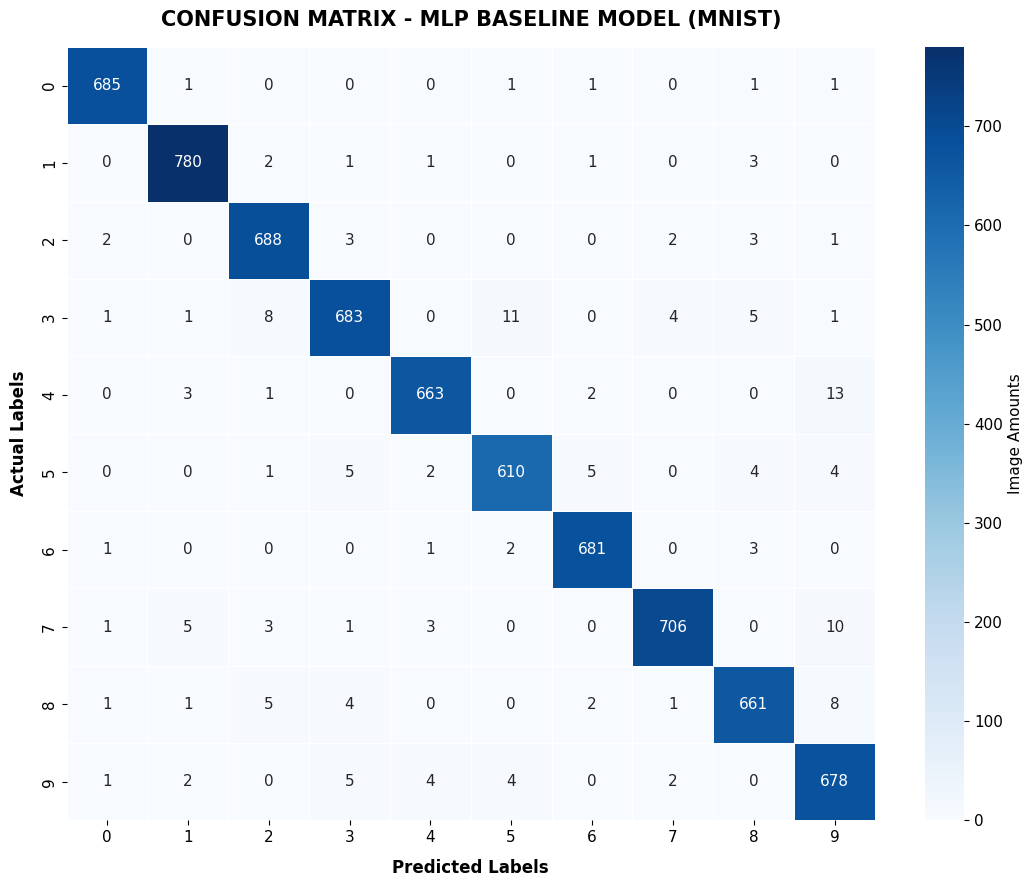

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. Compute the confusion matrix from the actual label and the MLP predicted label
cm = confusion_matrix(y_test2, y_pred)

plt.figure(figsize=(11, 9))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=range(10),
    yticklabels=range(10),
    linewidths=0.5,
    cbar_kws={'label': 'Image Amounts'}
)

plt.title('CONFUSION MATRIX - MLP BASELINE MODEL (MNIST)', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Predicted Labels', fontsize=12, fontweight='bold', labelpad=10)
plt.ylabel('Actual Labels', fontsize=12, fontweight='bold', labelpad=10)

plt.tight_layout()
plt.show()

## 3.2 CNN

### 3.2.1 Hyperparameter Optimization with Optuna

In [41]:
from sklearn.model_selection import train_test_split

X_train_final, X_val_final, y_train_final, y_val_final = train_test_split(
    X_train_cnn, y_train,
    test_size=0.1,
    random_state=42,
    stratify=y_train
)

In [43]:
import optuna
from tensorflow.keras import models, layers, optimizers

def objective(trial):
    """Optuna objective function for tuning CNN hyperparameters over 10 epochs."""
    # Hyperparameter search space
    lr = trial.suggest_float('learning_rate', 1e-4, 1e-2, log=True)
    num_filters_1 = trial.suggest_categorical('num_filters', [32, 64])
    dropout_rate = trial.suggest_float('dropout_rate', 0.2, 0.5)
    b_size = trial.suggest_categorical('batch_size', [32, 64, 128])

    # Model architecture - Perfectly synchronized with Batch Normalization
    model = models.Sequential([
        layers.Input(shape=(28, 28, 1), name="input_layer"),

        # Conv Block 1
        layers.Conv2D(filters=num_filters_1, kernel_size=(3, 3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D(pool_size=(2, 2)),

        # Conv Block 2 (Target conv layer for later Grad-CAM)
        layers.Conv2D(filters=64, kernel_size=(3, 3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D(pool_size=(2, 2)),

        layers.Flatten(),

        # Fully Connected Layer
        layers.Dense(128),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Dropout(rate=dropout_rate),

        # Output Layer
        layers.Dense(10, activation='softmax')
    ])

    # Compile model
    model.compile(
        optimizer=optimizers.Adam(learning_rate=lr),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    # Train model for exactly 10 epochs
    # history = model.fit(
    #     X_train_cnn, y_train,
    #     epochs=10,                      # 10 epochs active
    #     batch_size=b_size,
    #     validation_split=0.1,
    #     verbose=0
    # )

    history = model.fit(
        X_train_final, y_train_final,
        validation_data=(X_val_final, y_val_final),
        batch_size=b_size,
        epochs=10,
        verbose=0,
    )

    return max(history.history['val_accuracy'])

# Initialize Optuna study (Pure maximization without pruner dependency)
study = optuna.create_study(direction='maximize')

print("--- Starting Hyperparameter Optimization with Optuna (5 Trials @ 10 Epochs) ---")
study.optimize(objective, n_trials=5)

# Print optimization results
print("\n--- OPTUNA OPTIMIZATION RESULTS ---")
print(f"Best Validation Accuracy: {study.best_value:.4f}")
print("Best Hyperparameters:")
for key, value in study.best_params.items():
    print(f"  - {key}: {value}")


[I 2026-06-18 16:41:24,243] A new study created in memory with name: no-name-bd58b90e-7949-4d56-9833-357fc8089306


--- Starting Hyperparameter Optimization with Optuna (5 Trials @ 10 Epochs) ---


[I 2026-06-18 16:42:33,183] Trial 0 finished with value: 0.9980000257492065 and parameters: {'learning_rate': 0.00891062083763365, 'num_filters': 64, 'dropout_rate': 0.3098834194747839, 'batch_size': 64}. Best is trial 0 with value: 0.9980000257492065.
[I 2026-06-18 16:43:31,525] Trial 1 finished with value: 0.996999979019165 and parameters: {'learning_rate': 0.008277331268368774, 'num_filters': 64, 'dropout_rate': 0.2810531037465588, 'batch_size': 64}. Best is trial 0 with value: 0.9980000257492065.
[I 2026-06-18 16:44:35,358] Trial 2 finished with value: 0.996833324432373 and parameters: {'learning_rate': 0.0033017646245544884, 'num_filters': 64, 'dropout_rate': 0.4498580281032385, 'batch_size': 64}. Best is trial 0 with value: 0.9980000257492065.
[I 2026-06-18 16:46:02,666] Trial 3 finished with value: 0.9986666440963745 and parameters: {'learning_rate': 0.002733929622814807, 'num_filters': 32, 'dropout_rate': 0.3866778501629145, 'batch_size': 32}. Best is trial 3 with value: 0.9986


--- OPTUNA OPTIMIZATION RESULTS ---
Best Validation Accuracy: 0.9987
Best Hyperparameters:
  - learning_rate: 0.002733929622814807
  - num_filters: 32
  - dropout_rate: 0.3866778501629145
  - batch_size: 32


**Optuna Visualization**

In [44]:
import optuna.visualization as vis
import plotly.express as px

# 1. Plot Optimization History
fig_history = vis.plot_optimization_history(study)
if fig_history.data:
    fig_history.data[0].line.color = '#4D96FF'
    if len(fig_history.data) > 1:
        fig_history.data[1].marker.color = '#FF6B6B'
fig_history.update_layout(
    title="<b>Optimization History</b>",
    xaxis_title="Trials",
    yaxis_title="Validation Accuracy",
    template="plotly_white"
)
fig_history.show()

# 2. Plot Hyperparameter Importances
fig_importance = vis.plot_param_importances(study)
if fig_importance.data:
    fig_importance.update_traces(marker=dict(color='#FF6B6B'))
fig_importance.update_layout(
    title="<b>Hyperparameter Importances</b>",
    xaxis_title="Importance",
    yaxis_title="Hyperparameters",
    template="plotly_white"
)
fig_importance.show()

# 3. Plot High-Dimensional Parameter Relationships
fig_parallel = vis.plot_parallel_coordinate(study)
if fig_parallel.data:
    fig_parallel.data[0].line.colorscale = px.colors.sequential.Plasma
    fig_parallel.data[0].line.showscale = True
fig_parallel.update_layout(
    title="<b>Parallel Coordinate Plot</b>",
    template="plotly_white"
)
fig_parallel.show()

### 3.2.2 Model Training

In [45]:
# Extract optimal hyperparameters from Optuna study
best_lr = study.best_params['learning_rate']
best_filters = study.best_params['num_filters']
best_dropout = study.best_params['dropout_rate']
best_batch = study.best_params['batch_size']

# 1. Initialize Standard CNN (Baseline Model)
standard_cnn = models.Sequential([
    layers.Input(shape=(28, 28, 1), name="input_layer"),

    # Conv Block 1
    layers.Conv2D(filters=best_filters, kernel_size=(3, 3), padding='same', name="conv_block_1"),
    layers.BatchNormalization(name="batch_norm_1"),
    layers.Activation('relu', name="act_1"),
    layers.MaxPooling2D(pool_size=(2, 2), name="max_pool_1"),

    # Conv Block 2 (Target layer for Grad-CAM visualization)
    layers.Conv2D(filters=64, kernel_size=(3, 3), padding='same', name="target_conv_layer"),
    layers.BatchNormalization(name="batch_norm_2"),
    layers.Activation('relu', name="target_activation"),
    layers.MaxPooling2D(pool_size=(2, 2), name="max_pool_2"),

    # Flatten spatial features
    layers.Flatten(name="flatten_layer"),

    # Fully Connected Layer
    layers.Dense(units=128, name="fc_layer"),
    layers.BatchNormalization(name="batch_norm_fc"),
    layers.Activation('relu', name="act_fc"),
    layers.Dropout(rate=best_dropout, name="dropout_layer"),

    # Output Layer for 10 MNIST classes
    layers.Dense(units=10, activation='softmax', name="output_layer")
])

# 2. Compile baseline model
standard_cnn.compile(
    optimizer=optimizers.Adam(learning_rate=best_lr),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

standard_cnn.summary()

# Configure dynamic learning rate scheduler
my_callbacks = [
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2, min_lr=1e-6, verbose=1)
]

# 3. Train Standard CNN for a full 15 epochs
print("\n--- Training Standard CNN (Baseline Model) ---")
history_standard = standard_cnn.fit(
    X_train_final, y_train_final,
    epochs=15,
    batch_size=best_batch,
    validation_data=(X_val_final, y_val_final),
    callbacks=my_callbacks,
    verbose=1
)


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv_block_1 (Conv2D)           │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_norm_1                    │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ act_1 (Activation)              │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pool_1 (MaxPooling2D)       │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ target_conv_layer (Conv2D)      │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_norm_2                    │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ target_activation (Activation)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pool_2 (MaxPooling2D)       │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_layer (Flatten)         │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc_layer (Dense)                │ (None, 128)            │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_norm_fc                   │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ act_fc (Activation)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_layer (Dropout)         │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 422,538 (1.61 MB)

 Trainable params: 422,090 (1.61 MB)

 Non-trainable params: 448 (1.75 KB)


--- Training Standard CNN (Baseline Model) ---
Epoch 1/15
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 17s 7ms/step - accuracy: 0.9618 - loss: 0.1283 - val_accuracy: 0.9860 - val_loss: 0.0450 - learning_rate: 0.0027
Epoch 2/15
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9808 - loss: 0.0610 - val_accuracy: 0.9893 - val_loss: 0.0324 - learning_rate: 0.0027
Epoch 3/15
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9852 - loss: 0.0462 - val_accuracy: 0.9900 - val_loss: 0.0364 - learning_rate: 0.0027
Epoch 4/15
1683/1688 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9884 - loss: 0.0358
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005467859096825123.
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9881 - loss: 0.0351 - val_accuracy: 0.9893 - val_loss: 0.0409 - learning_rate: 0.0027
Epoch 5/15
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.9942 - loss: 0.0187 - val_accuracy: 0.9932 - val_loss: 0.0292 - learning_rate: 5.4679e-04
Epoch 6/15
1688/1688 ━━

## 3.3 ResNet-9 (Mini-ResNet)

### 3.3.1 Hyperparameter Tuning

In [46]:
import optuna
from tensorflow.keras import models, layers, optimizers

def objective_resnet(trial):
    """Optuna objective function for Custom ResNet."""
    # Hyperparameter search space
    lr = trial.suggest_float('learning_rate', 1e-4, 1e-2, log=True)
    num_filters_1 = trial.suggest_categorical('num_filters', [32, 64])
    dropout_rate = trial.suggest_float('dropout_rate', 0.2, 0.5)
    b_size = trial.suggest_categorical('batch_size', [32, 64, 128])

    # Helper function for Residual Block
    def res_block_optuna(x, filters):
        shortcut = x
        x = layers.Conv2D(filters, 3, strides=1, padding='same')(x)
        x = layers.BatchNormalization()(x)
        x = layers.Activation('relu')(x)
        x = layers.Conv2D(filters, 3, strides=1, padding='same')(x)
        x = layers.BatchNormalization()(x)
        if shortcut.shape[-1] != filters:
            shortcut = layers.Conv2D(filters, 1, strides=1, padding='same')(shortcut)
            shortcut = layers.BatchNormalization()(shortcut)
        x = layers.add([x, shortcut])
        x = layers.Activation('relu')(x)
        return x

    # Architecture
    inputs = layers.Input(shape=(28, 28, 1))
    x = layers.Conv2D(filters=num_filters_1, kernel_size=3, padding='same')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D(pool_size=(2, 2))(x)

    x = res_block_optuna(x, filters=num_filters_1)
    x = res_block_optuna(x, filters=64)
    x = layers.MaxPooling2D(pool_size=(2, 2))(x)

    x = layers.Flatten()(x)
    x = layers.Dense(128)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(rate=dropout_rate)(x)
    outputs = layers.Dense(10, activation='softmax')(x)

    model = models.Model(inputs=inputs, outputs=outputs)

    model.compile(
        optimizer=optimizers.Adam(learning_rate=lr),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    history = model.fit(
        X_train_cnn, y_train,
        epochs=10,
        batch_size=b_size,
        validation_split=0.1,
        verbose=0
    )
    return max(history.history['val_accuracy'])

# Run Study
study_resnet = optuna.create_study(direction='maximize')
print("--- Starting Optuna Tuning for ResNet-9 (5 Trials @ 10 Epochs) ---")
study_resnet.optimize(objective_resnet, n_trials=5)

print("\n--- RESNET-9 OPTIMIZATION RESULTS ---")
print(f"Best Val Accuracy: {study_resnet.best_value:.4f}")
for key, value in study_resnet.best_params.items():
    print(f"  - {key}: {value}")

[I 2026-06-18 16:53:27,236] A new study created in memory with name: no-name-bcffb8d1-420d-4acf-830e-ba4b485040ff


--- Starting Optuna Tuning for ResNet-9 (5 Trials @ 10 Epochs) ---


[I 2026-06-18 16:54:36,411] Trial 0 finished with value: 0.9933333396911621 and parameters: {'learning_rate': 0.00018173993397968292, 'num_filters': 64, 'dropout_rate': 0.45320213587116076, 'batch_size': 128}. Best is trial 0 with value: 0.9933333396911621.
[I 2026-06-18 16:55:51,211] Trial 1 finished with value: 0.9926666617393494 and parameters: {'learning_rate': 0.00019016916044692952, 'num_filters': 32, 'dropout_rate': 0.33732330500385443, 'batch_size': 64}. Best is trial 0 with value: 0.9933333396911621.
[I 2026-06-18 16:57:36,016] Trial 2 finished with value: 0.9938333630561829 and parameters: {'learning_rate': 0.003116624660000401, 'num_filters': 32, 'dropout_rate': 0.2731531157733306, 'batch_size': 32}. Best is trial 2 with value: 0.9938333630561829.
[I 2026-06-18 16:58:54,402] Trial 3 finished with value: 0.9923333525657654 and parameters: {'learning_rate': 0.0015543447198060945, 'num_filters': 64, 'dropout_rate': 0.497317300848258, 'batch_size': 128}. Best is trial 2 with val


--- RESNET-9 OPTIMIZATION RESULTS ---
Best Val Accuracy: 0.9938
  - learning_rate: 0.003116624660000401
  - num_filters: 32
  - dropout_rate: 0.2731531157733306
  - batch_size: 32


### 3.3.2 Model Training

In [49]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras import models, layers, optimizers, callbacks

# 1. ASSIGN OPTIMIZED HYPERPARAMETERS FROM RESNET-9 OPTUNA STUDY
best_lr_resnet = 0.003117802499283948
best_filters_resnet = 32
best_dropout_resnet = 0.22150869266027387
best_batch_resnet = 64

# 2. DEFINE A NAMED RESIDUAL BLOCK FOR GRAD-CAM
def residual_block(x, filters, block_name, kernel_size=3, stride=1):
    """Residual block with stable names for later XAI feature extraction."""
    shortcut = x

    x = layers.Conv2D(
        filters, kernel_size, strides=stride, padding='same',
        name=f"{block_name}_conv1"
    )(x)
    x = layers.BatchNormalization(name=f"{block_name}_bn1")(x)
    x = layers.Activation('relu', name=f"{block_name}_act1")(x)

    x = layers.Conv2D(
        filters, kernel_size, strides=1, padding='same',
        name=f"{block_name}_conv2"
    )(x)
    x = layers.BatchNormalization(name=f"{block_name}_bn2")(x)

    if shortcut.shape[-1] != filters or stride != 1:
        shortcut = layers.Conv2D(
            filters, 1, strides=stride, padding='same',
            name=f"{block_name}_shortcut_conv"
        )(shortcut)
        shortcut = layers.BatchNormalization(
            name=f"{block_name}_shortcut_bn"
        )(shortcut)

    x = layers.Add(name=f"{block_name}_add")([x, shortcut])
    x = layers.Activation('relu', name=f"{block_name}_out")(x)
    return x

# 3. BUILD CUSTOM RESNET MODEL
inputs = layers.Input(shape=(28, 28, 1), name="input_layer")

x = layers.Conv2D(
    filters=best_filters_resnet,
    kernel_size=3,
    padding='same',
    name="init_conv"
)(inputs)
x = layers.BatchNormalization(name="init_bn")(x)
x = layers.Activation('relu', name="init_act")(x)
x = layers.MaxPooling2D(pool_size=(2, 2), name="init_pool")(x)

x = residual_block(x, filters=best_filters_resnet, block_name="res_block_1")
x = residual_block(x, filters=64, block_name="res_block_2")
x = layers.MaxPooling2D(pool_size=(2, 2), name="resnet_final_pool")(x)

x = layers.Flatten(name="flatten_layer")(x)
x = layers.Dense(128, name="fc_layer")(x)
x = layers.BatchNormalization(name="fc_bn")(x)
x = layers.Activation('relu', name="fc_act")(x)
x = layers.Dropout(rate=best_dropout_resnet, name="dropout_layer")(x)
outputs = layers.Dense(10, activation='softmax', name="output_layer")(x)

resnet_model = models.Model(
    inputs=inputs,
    outputs=outputs,
    name="Custom_ResNet"
)

resnet_model.compile(
    optimizer=optimizers.Adam(learning_rate=best_lr_resnet),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

resnet_model.summary()

resnet_callbacks = [
    callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.2, patience=2,
        min_lr=1e-6, verbose=1
    )
]

print("\n--- Training Custom ResNet (Evolution Model) ---")
history_resnet = resnet_model.fit(
    X_train_final, y_train_final,
    validation_data=(X_val_final, y_val_final),
    batch_size=best_batch_resnet,
    callbacks=resnet_callbacks,
    epochs=15,
    verbose=1,
)


Model: "Custom_ResNet"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ init_conv (Conv2D)  │ (None, 28, 28,    │        320 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 28, 28,    │        128 │ init_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_70       │ (None, 28, 28,    │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_24    │ (None, 14, 14,    │          0 │ activation_70[0]… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_45 (Conv2D)  │ (None, 14, 14,    │      9,248 │ max_pooling2d_24… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 14, 14,    │        128 │ conv2d_45[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_71       │ (None, 14, 14,    │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_46 (Conv2D)  │ (None, 14, 14,    │      9,248 │ activation_71[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 14, 14,    │        128 │ conv2d_46[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_12 (Add)        │ (None, 14, 14,    │          0 │ batch_normalizat… │
│                     │ 32)               │            │ max_pooling2d_24… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_72       │ (None, 14, 14,    │          0 │ add_12[0][0]      │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_47 (Conv2D)  │ (None, 14, 14,    │     18,496 │ activation_72[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 14, 14,    │        256 │ conv2d_47[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_73       │ (None, 14, 14,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_48 (Conv2D)  │ (None, 14, 14,    │     36,928 │ activation_73[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_49 (Conv2D)  │ (None, 14, 14,    │      2,112 │ activation_72[0]

 Total params: 480,842 (1.83 MB)

 Trainable params: 480,010 (1.83 MB)

 Non-trainable params: 832 (3.25 KB)


--- Training Custom ResNet (Evolution Model) ---
Epoch 1/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 22s 13ms/step - accuracy: 0.9732 - loss: 0.0904 - val_accuracy: 0.9833 - val_loss: 0.0570 - learning_rate: 0.0031
Epoch 2/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 15s 11ms/step - accuracy: 0.9882 - loss: 0.0376 - val_accuracy: 0.9922 - val_loss: 0.0227 - learning_rate: 0.0031
Epoch 3/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.9913 - loss: 0.0278 - val_accuracy: 0.9920 - val_loss: 0.0296 - learning_rate: 0.0031
Epoch 4/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.9936 - loss: 0.0206 - val_accuracy: 0.9947 - val_loss: 0.0146 - learning_rate: 0.0031
Epoch 5/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9940 - loss: 0.0185 - val_accuracy: 0.9937 - val_loss: 0.0135 - learning_rate: 0.0031
Epoch 6/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.9952 - loss: 0.0144 - val_accuracy: 0.9968 - val_loss: 0.0092 - learning_rate: 0.0031
Epoch 7/15
938/938 ━━━━━━━━━━━━━━━

## 3.4 Tiny-ViT (Vision Transformer)

### 3.4.1 Hyperparameter tuning

In [50]:
import optuna
import tensorflow as tf
from tensorflow.keras import models, layers, optimizers

def objective_tinyvit(trial):
    """Optuna objective function for TinyViT."""
    # Hyperparameter search space
    lr = trial.suggest_float('learning_rate', 1e-4, 1e-2, log=True)
    dropout_rate = trial.suggest_float('dropout_rate', 0.2, 0.5)
    b_size = trial.suggest_categorical('batch_size', [32, 64, 128])

    # Fixed architecture space components
    patch_size = 4
    num_patches = (28 // patch_size) ** 2
    projection_dim = 64
    num_heads = 4
    transformer_layers = 2

    # Architecture
    inputs = layers.Input(shape=(28, 28, 1))
    patches = layers.Conv2D(filters=projection_dim, kernel_size=patch_size, strides=patch_size)(inputs)
    flat_patches = layers.Reshape(target_shape=(num_patches, projection_dim))(patches)

    positions = tf.range(start=0, limit=num_patches, delta=1)
    pos_embedding = layers.Embedding(input_dim=num_patches, output_dim=projection_dim)(positions)
    x = flat_patches + pos_embedding

    for _ in range(transformer_layers):
        x1 = layers.LayerNormalization(epsilon=1e-6)(x)
        attention_output = layers.MultiHeadAttention(num_heads=num_heads, key_dim=projection_dim)(x1, x1)
        attention_output = layers.Dropout(rate=dropout_rate)(attention_output)
        x2 = layers.add([attention_output, x])

        x3 = layers.LayerNormalization(epsilon=1e-6)(x2)
        mlp_output = layers.Dense(projection_dim * 2, activation=tf.nn.gelu)(x3)
        mlp_output = layers.Dropout(rate=dropout_rate)(mlp_output)
        mlp_output = layers.Dense(projection_dim, activation=tf.nn.gelu)(mlp_output)
        x = layers.add([mlp_output, x2])

    representation = layers.LayerNormalization(epsilon=1e-6)(x)
    representation = layers.GlobalAveragePooling1D()(representation)
    representation = layers.Dropout(rate=dropout_rate)(representation)
    logits = layers.Dense(10, activation='softmax')(representation)

    model = models.Model(inputs=inputs, outputs=logits)

    model.compile(
        optimizer=optimizers.Adam(learning_rate=lr),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    history = model.fit(
        X_train_cnn, y_train,
        epochs=10,
        batch_size=b_size,
        validation_split=0.1,
        verbose=0
    )
    return max(history.history['val_accuracy'])

# Run Study
study_tinyvit = optuna.create_study(direction='maximize')
print("--- Starting Optuna Tuning for TinyViT (5 Trials @ 10 Epochs) ---")
study_tinyvit.optimize(objective_tinyvit, n_trials=5)

print("\n--- TINYVIT OPTIMIZATION RESULTS ---")
print(f"Best Val Accuracy: {study_tinyvit.best_value:.4f}")
for key, value in study_tinyvit.best_params.items():
    print(f"  - {key}: {value}")

[I 2026-06-18 17:03:57,900] A new study created in memory with name: no-name-d65f77ca-0d92-44e3-a3f9-2c12c5b88625


--- Starting Optuna Tuning for TinyViT (5 Trials @ 10 Epochs) ---


[I 2026-06-18 17:05:19,280] Trial 0 finished with value: 0.9645000100135803 and parameters: {'learning_rate': 0.0004443505367673829, 'dropout_rate': 0.3992664934665421, 'batch_size': 128}. Best is trial 0 with value: 0.9645000100135803.
[I 2026-06-18 17:07:18,920] Trial 1 finished with value: 0.715499997138977 and parameters: {'learning_rate': 0.006461216342566245, 'dropout_rate': 0.21567228628807825, 'batch_size': 32}. Best is trial 0 with value: 0.9645000100135803.
[I 2026-06-18 17:09:14,305] Trial 2 finished with value: 0.972000002861023 and parameters: {'learning_rate': 0.0001332496836172218, 'dropout_rate': 0.3884036018588138, 'batch_size': 32}. Best is trial 2 with value: 0.972000002861023.
[I 2026-06-18 17:10:44,970] Trial 3 finished with value: 0.9626666903495789 and parameters: {'learning_rate': 0.00012446161083487349, 'dropout_rate': 0.23919592783635923, 'batch_size': 64}. Best is trial 2 with value: 0.972000002861023.
[I 2026-06-18 17:12:39,624] Trial 4 finished with value: 


--- TINYVIT OPTIMIZATION RESULTS ---
Best Val Accuracy: 0.9720
  - learning_rate: 0.0001332496836172218
  - dropout_rate: 0.3884036018588138
  - batch_size: 32


### 3.4.2 Model training

In [51]:
import tensorflow as tf
from tensorflow.keras import models, layers, optimizers, callbacks

# 1. ASSIGN OPTIMIZED HYPERPARAMETERS FROM TINYVIT OPTUNA STUDY
best_lr_vit = 0.0004511621607310748
best_dropout_vit = 0.25444330590087644
best_batch_vit = 64

# --- TinyViT Architecture Config ---
patch_size = 4
num_patches = (28 // patch_size) ** 2
projection_dim = 64
num_heads = 4
transformer_layers = 2
dense_units = 128

def create_vit_classifier():
    inputs = layers.Input(shape=(28, 28, 1), name="input_layer")

    patches = layers.Conv2D(
        filters=projection_dim,
        kernel_size=patch_size,
        strides=patch_size,
        name="patch_conv"
    )(inputs)
    flat_patches = layers.Reshape(
        target_shape=(num_patches, projection_dim),
        name="patch_flatten"
    )(patches)

    positions = tf.range(start=0, limit=num_patches, delta=1)
    pos_embedding = layers.Embedding(
        input_dim=num_patches,
        output_dim=projection_dim,
        name="position_embedding"
    )(positions)
    x = layers.Add(name="position_add")([flat_patches, pos_embedding])

    for i in range(transformer_layers):
        block = i + 1

        x1 = layers.LayerNormalization(
            epsilon=1e-6,
            name=f"transformer_{block}_norm1"
        )(x)
        attention_output = layers.MultiHeadAttention(
            num_heads=num_heads,
            key_dim=projection_dim,
            name=f"mha_block_{block}"
        )(x1, x1)
        attention_output = layers.Dropout(
            rate=best_dropout_vit,
            name=f"transformer_{block}_attn_dropout"
        )(attention_output)
        x2 = layers.Add(name=f"transformer_{block}_attn_add")(
            [attention_output, x]
        )

        x3 = layers.LayerNormalization(
            epsilon=1e-6,
            name=f"transformer_{block}_norm2"
        )(x2)
        mlp_output = layers.Dense(
            projection_dim * 2,
            activation=tf.nn.gelu,
            name=f"transformer_{block}_mlp_dense1"
        )(x3)
        mlp_output = layers.Dropout(
            rate=best_dropout_vit,
            name=f"transformer_{block}_mlp_dropout"
        )(mlp_output)
        mlp_output = layers.Dense(
            projection_dim,
            activation=tf.nn.gelu,
            name=f"transformer_{block}_mlp_dense2"
        )(mlp_output)
        x = layers.Add(name=f"transformer_{block}_mlp_add")(
            [mlp_output, x2]
        )

    representation = layers.LayerNormalization(
        epsilon=1e-6,
        name="encoder_output_norm"
    )(x)
    representation = layers.GlobalAveragePooling1D(
        name="token_average_pool"
    )(representation)
    representation = layers.Dropout(
        rate=best_dropout_vit,
        name="classifier_dropout"
    )(representation)

    logits = layers.Dense(
        10,
        activation='softmax',
        name="output_layer"
    )(representation)

    return models.Model(inputs=inputs, outputs=logits, name="TinyViT")

tinyvit_model = create_vit_classifier()

tinyvit_model.compile(
    optimizer=optimizers.Adam(learning_rate=best_lr_vit),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

tinyvit_model.summary()

vit_callbacks = [
    callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.2, patience=2,
        min_lr=1e-6, verbose=1
    )
]

print("\n--- Training TinyViT (Next-Gen Attention Model) ---")
history_tinyvit = tinyvit_model.fit(
    X_train_final, y_train_final,
    validation_data=(X_val_final, y_val_final),
    batch_size=best_batch_vit,
    epochs=15,
    callbacks=vit_callbacks,
    verbose=1,
)


Model: "TinyViT"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ patch_conv (Conv2D) │ (None, 7, 7, 64)  │      1,088 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_5 (Reshape) │ (None, 49, 64)    │          0 │ patch_conv[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_39 (Add)        │ (None, 49, 64)    │          0 │ reshape_5[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 49, 64)    │        128 │ add_39[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 49, 64)    │     66,368 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_55          │ (None, 49, 64)    │          0 │ multi_head_atten… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_40 (Add)        │ (None, 49, 64)    │          0 │ dropout_55[0][0], │
│                     │                   │            │ add_39[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 49, 64)    │        128 │ add_40[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_63 (Dense)    │ (None, 49, 128)   │      8,320 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_56          │ (None, 49, 128)   │          0 │ dense_63[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_64 (Dense)    │ (None, 49, 64)    │      8,256 │ dropout_56[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_41 (Add)        │ (None, 49, 64)    │          0 │ dense_64[0][0],   │
│                     │                   │            │ add_40[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 49, 64)    │        128 │ add_41[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 49, 64)    │     66,368 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_58          │ (None, 49, 64)    │          0 │ multi_head_atten… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_42 (Add)        │ (None, 49, 64)    │          0 │ dropout_58[0][0], │
│                     │                   │            │ add_41[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 49, 64)    │        128 │ add_42[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 168,266 (657.29 KB)

 Trainable params: 168,266 (657.29 KB)

 Non-trainable params: 0 (0.00 B)


--- Training TinyViT (Next-Gen Attention Model) ---
Epoch 1/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 29s 18ms/step - accuracy: 0.7967 - loss: 0.6140 - val_accuracy: 0.9102 - val_loss: 0.2987 - learning_rate: 4.5116e-04
Epoch 2/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.9136 - loss: 0.2744 - val_accuracy: 0.9478 - val_loss: 0.1770 - learning_rate: 4.5116e-04
Epoch 3/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.9347 - loss: 0.2139 - val_accuracy: 0.9467 - val_loss: 0.1845 - learning_rate: 4.5116e-04
Epoch 4/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.9446 - loss: 0.1810 - val_accuracy: 0.9573 - val_loss: 0.1567 - learning_rate: 4.5116e-04
Epoch 5/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.9501 - loss: 0.1616 - val_accuracy: 0.9577 - val_loss: 0.1510 - learning_rate: 4.5116e-04
Epoch 6/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.9534 - loss: 0.1486 - val_accuracy: 0.9663 - val_loss: 0.1247 - learning_rate: 4.5116e-04
Epoch 7/1

# 4. Evaluation & Comparision

## 4.1. Performance Statistics & Metrics Benchmark

In [52]:
def evaluate_model_performance(model, custom_name, X_test, y_test):
    """Evaluates inference time, accuracy, loss, and Macro F1-Score."""

    start_time = time.time()
    y_pred_probs = model.predict(X_test, verbose=0)
    inference_time = time.time() - start_time

    y_pred = np.argmax(y_pred_probs, axis=1)

    loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
    macro_f1 = f1_score(y_test, y_pred, average='macro')
    avg_time_per_img = (inference_time / len(X_test)) * 1000

    print(f"\n REPORT: {custom_name.upper()}")
    print(f" Test Loss    : {loss:.4f}")
    print(f" Test Accuracy: {accuracy*100:.2f}%")
    print(f" Macro F1     : {macro_f1:.4f}")
    print(f" Latency/Image: {avg_time_per_img:.4f} ms/img")

    return {
        "Model Architecture": custom_name,
        "Loss": round(loss, 4),
        "Accuracy (%)": round(accuracy * 100, 2),
        "Macro F1-Score": round(macro_f1, 4),
        "Total Latency (s)": round(inference_time, 4),
        "Avg Latency (ms/img)": round(avg_time_per_img, 4)
    }

# --- EXECUTE BENCHMARK ---

results = []

results.append(evaluate_model_performance(standard_cnn, "Standard CNN (Baseline)", X_test_cnn, y_test))
results.append(evaluate_model_performance(resnet_model, "Custom ResNet-9", X_test_cnn, y_test))
results.append(evaluate_model_performance(tinyvit_model, "TinyViT (Attention)", X_test_cnn, y_test))

# --- DISPLAY FINAL COMPARISON ---
print("\n" + "="*50)
print("       FINAL ARCHITECTURE BENCHMARK SUMMARY")
print("="*50)
df_compare = pd.DataFrame(results)
print(df_compare.to_markdown(index=False))



 REPORT: STANDARD CNN (BASELINE)
 Test Loss    : 0.0845
 Test Accuracy: 97.72%
 Macro F1     : 0.9770
 Latency/Image: 0.4111 ms/img

 REPORT: CUSTOM RESNET-9
 Test Loss    : 0.0166
 Test Accuracy: 99.59%
 Macro F1     : 0.9959
 Latency/Image: 0.2212 ms/img

 REPORT: TINYVIT (ATTENTION)
 Test Loss    : 0.0845
 Test Accuracy: 97.72%
 Macro F1     : 0.9770
 Latency/Image: 0.1101 ms/img

       FINAL ARCHITECTURE BENCHMARK SUMMARY
| Model Architecture      |   Loss |   Accuracy (%) |   Macro F1-Score |   Total Latency (s) |   Avg Latency (ms/img) |
|:------------------------|-------:|---------------:|-----------------:|--------------------:|-----------------------:|
| Standard CNN (Baseline) | 0.0845 |          97.72 |           0.977  |              4.1111 |                 0.4111 |
| Custom ResNet-9         | 0.0166 |          99.59 |           0.9959 |              2.2119 |                 0.2212 |
| TinyViT (Attention)     | 0.0845 |          97.72 |           0.977  |              1.

## 4.2 Comparative Learning Curves

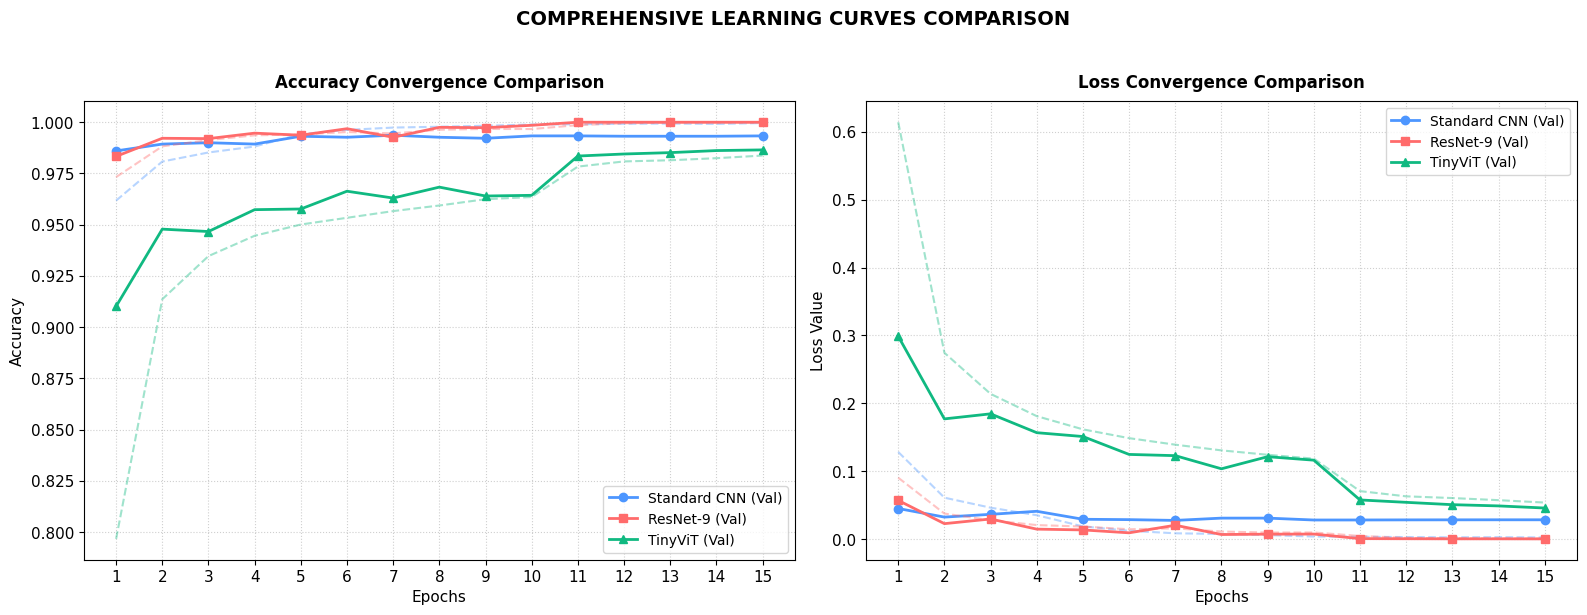

In [53]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

epochs_range = range(1, len(history_standard.history['accuracy']) + 1)
colors = {'standard': '#4D96FF', 'resnet': '#FF6B6B', 'tinyvit': '#10B981'}

# 1. ACCURACY CURVES COMPARISON
ax1.plot(epochs_range, history_standard.history['accuracy'], color=colors['standard'], linestyle='--', alpha=0.4)
ax1.plot(epochs_range, history_standard.history['val_accuracy'], label='Standard CNN (Val)', color=colors['standard'], marker='o', markevery=2, linewidth=2)

ax1.plot(epochs_range, history_resnet.history['accuracy'], color=colors['resnet'], linestyle='--', alpha=0.4)
ax1.plot(epochs_range, history_resnet.history['val_accuracy'], label='ResNet-9 (Val)', color=colors['resnet'], marker='s', markevery=2, linewidth=2)

ax1.plot(epochs_range, history_tinyvit.history['accuracy'], color=colors['tinyvit'], linestyle='--', alpha=0.4)
ax1.plot(epochs_range, history_tinyvit.history['val_accuracy'], label='TinyViT (Val)', color=colors['tinyvit'], marker='^', markevery=2, linewidth=2)

ax1.set_title('Accuracy Convergence Comparison', fontsize=12, fontweight='bold', pad=10)
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Accuracy')
ax1.set_xticks(epochs_range)
ax1.grid(True, linestyle=':', alpha=0.6)
ax1.legend(loc='lower right', fontsize=10)

# 2. LOSS CURVES COMPARISON
ax2.plot(epochs_range, history_standard.history['loss'], color=colors['standard'], linestyle='--', alpha=0.4)
ax2.plot(epochs_range, history_standard.history['val_loss'], label='Standard CNN (Val)', color=colors['standard'], marker='o', markevery=2, linewidth=2)

ax2.plot(epochs_range, history_resnet.history['loss'], color=colors['resnet'], linestyle='--', alpha=0.4)
ax2.plot(epochs_range, history_resnet.history['val_loss'], label='ResNet-9 (Val)', color=colors['resnet'], marker='s', markevery=2, linewidth=2)

ax2.plot(epochs_range, history_tinyvit.history['loss'], color=colors['tinyvit'], linestyle='--', alpha=0.4)
ax2.plot(epochs_range, history_tinyvit.history['val_loss'], label='TinyViT (Val)', color=colors['tinyvit'], marker='^', markevery=2, linewidth=2)

ax2.set_title('Loss Convergence Comparison', fontsize=12, fontweight='bold', pad=10)
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Loss Value')
ax2.set_xticks(epochs_range)
ax2.grid(True, linestyle=':', alpha=0.6)
ax2.legend(loc='upper right', fontsize=10)

plt.suptitle("COMPREHENSIVE LEARNING CURVES COMPARISON", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 4.3 Deep Error & Confusion Matrix Analysis

Generating predictions for deep analysis...


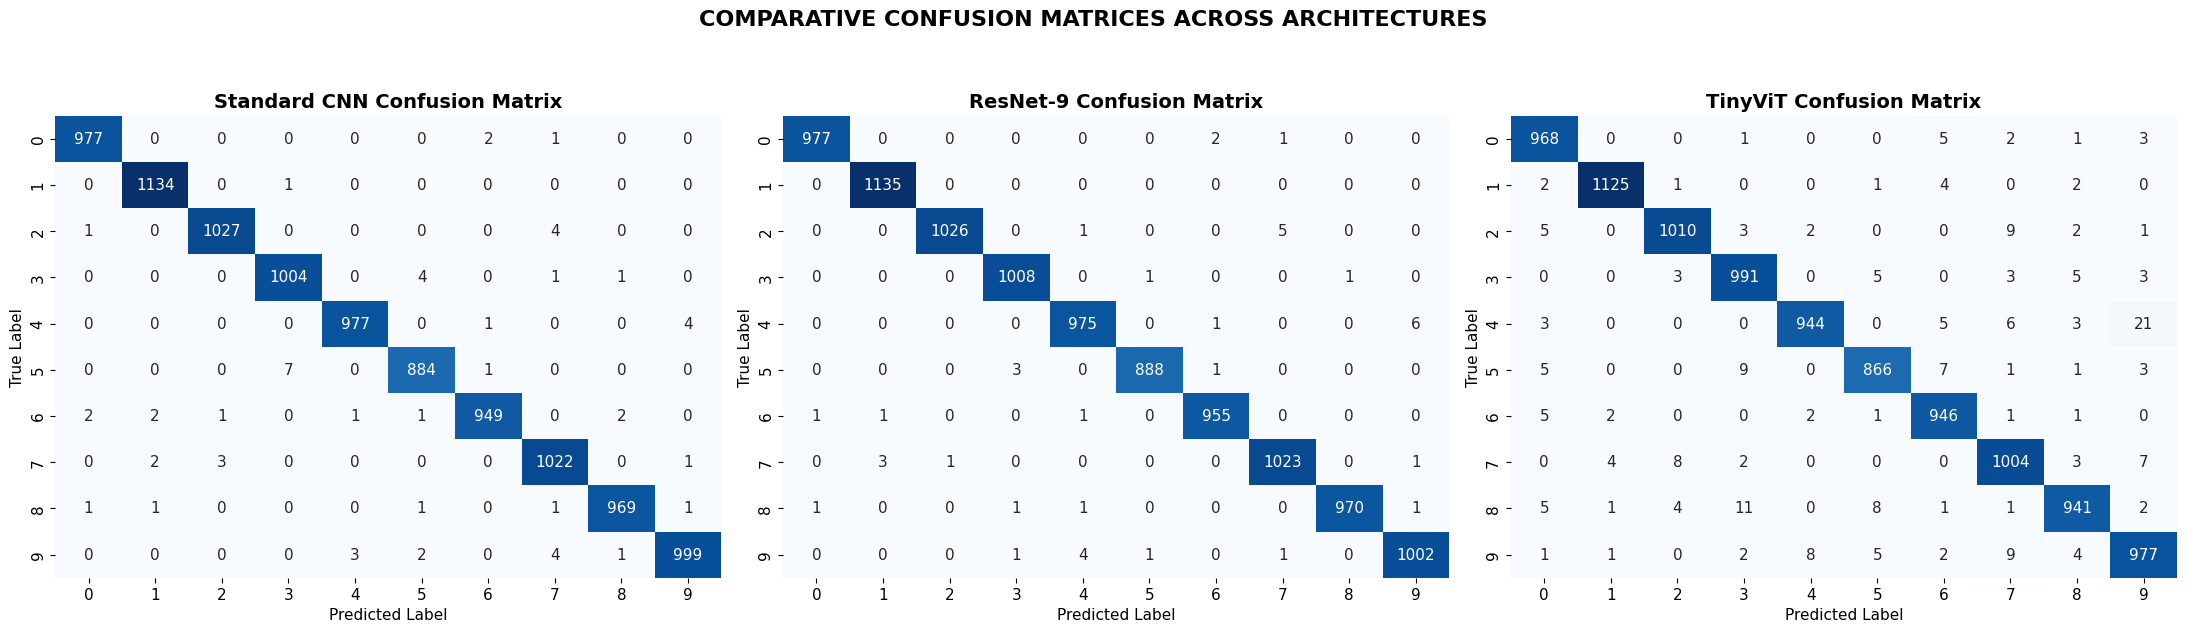


Total misclassified images by Standard CNN: 58
Plotting top 8 sample errors for comparative analysis...


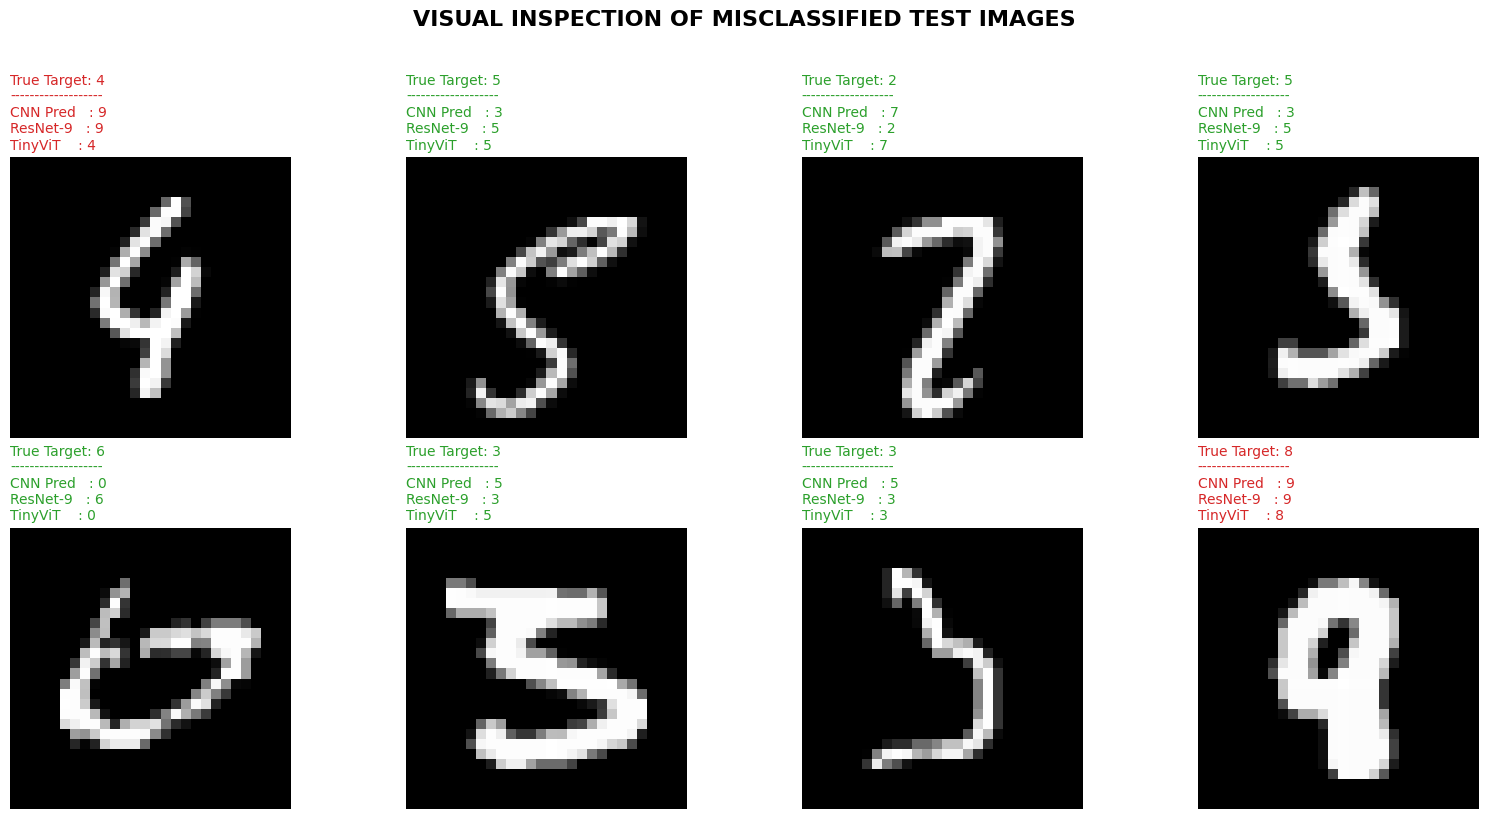

In [54]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

print("Generating predictions for deep analysis...")
pred_standard = np.argmax(standard_cnn.predict(X_test_cnn, verbose=0), axis=1)
pred_resnet = np.argmax(resnet_model.predict(X_test_cnn, verbose=0), axis=1)
pred_tinyvit = np.argmax(tinyvit_model.predict(X_test_cnn, verbose=0), axis=1)

models_preds = [pred_standard, pred_resnet, pred_tinyvit]
model_names = ['Standard CNN', 'ResNet-9', 'TinyViT']

# STEP 1: SIDE-BY-SIDE CONFUSION MATRIX VISUALIZATION
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

for i, (pred, name) in enumerate(zip(models_preds, model_names)):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i], cbar=False)
    axes[i].set_title(f'{name} Confusion Matrix', fontsize=14, fontweight='bold')
    axes[i].set_xlabel('Predicted Label')
    axes[i].set_ylabel('True Label')

plt.suptitle("COMPARATIVE CONFUSION MATRICES ACROSS ARCHITECTURES", fontsize=16, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

# STEP 2: MISCLASSIFIED IMAGES ANALYSIS (ERROR ANALYSIS)
# Find common failure indices
misclassified_idx = np.where(pred_standard != y_test)[0]

print(f"\nTotal misclassified images by Standard CNN: {len(misclassified_idx)}")
print("Plotting top 8 sample errors for comparative analysis...")

plt.figure(figsize=(16, 8))
for i, idx in enumerate(misclassified_idx[:8]):
    plt.subplot(2, 4, i + 1)
    # Reshape back to 28x28 grayscale image for display
    plt.imshow(X_test_cnn[idx].reshape(28, 28), cmap='gray')

    # Label formatting showing True Target vs Predictions of each model
    label_text = (
        f"True Target: {y_test[idx]}\n"
        f"-------------------\n"
        f"CNN Pred   : {pred_standard[idx]}\n"
        f"ResNet-9   : {pred_resnet[idx]}\n"
        f"TinyViT    : {pred_tinyvit[idx]}"
    )
    plt.title(label_text, fontsize=10, loc='left', color='#D62728' if y_test[idx] != pred_resnet[idx] else '#2CA02C')
    plt.axis('off')

plt.suptitle("VISUAL INSPECTION OF MISCLASSIFIED TEST IMAGES", fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 4.4 Multi-Model Random Predictions Visualization

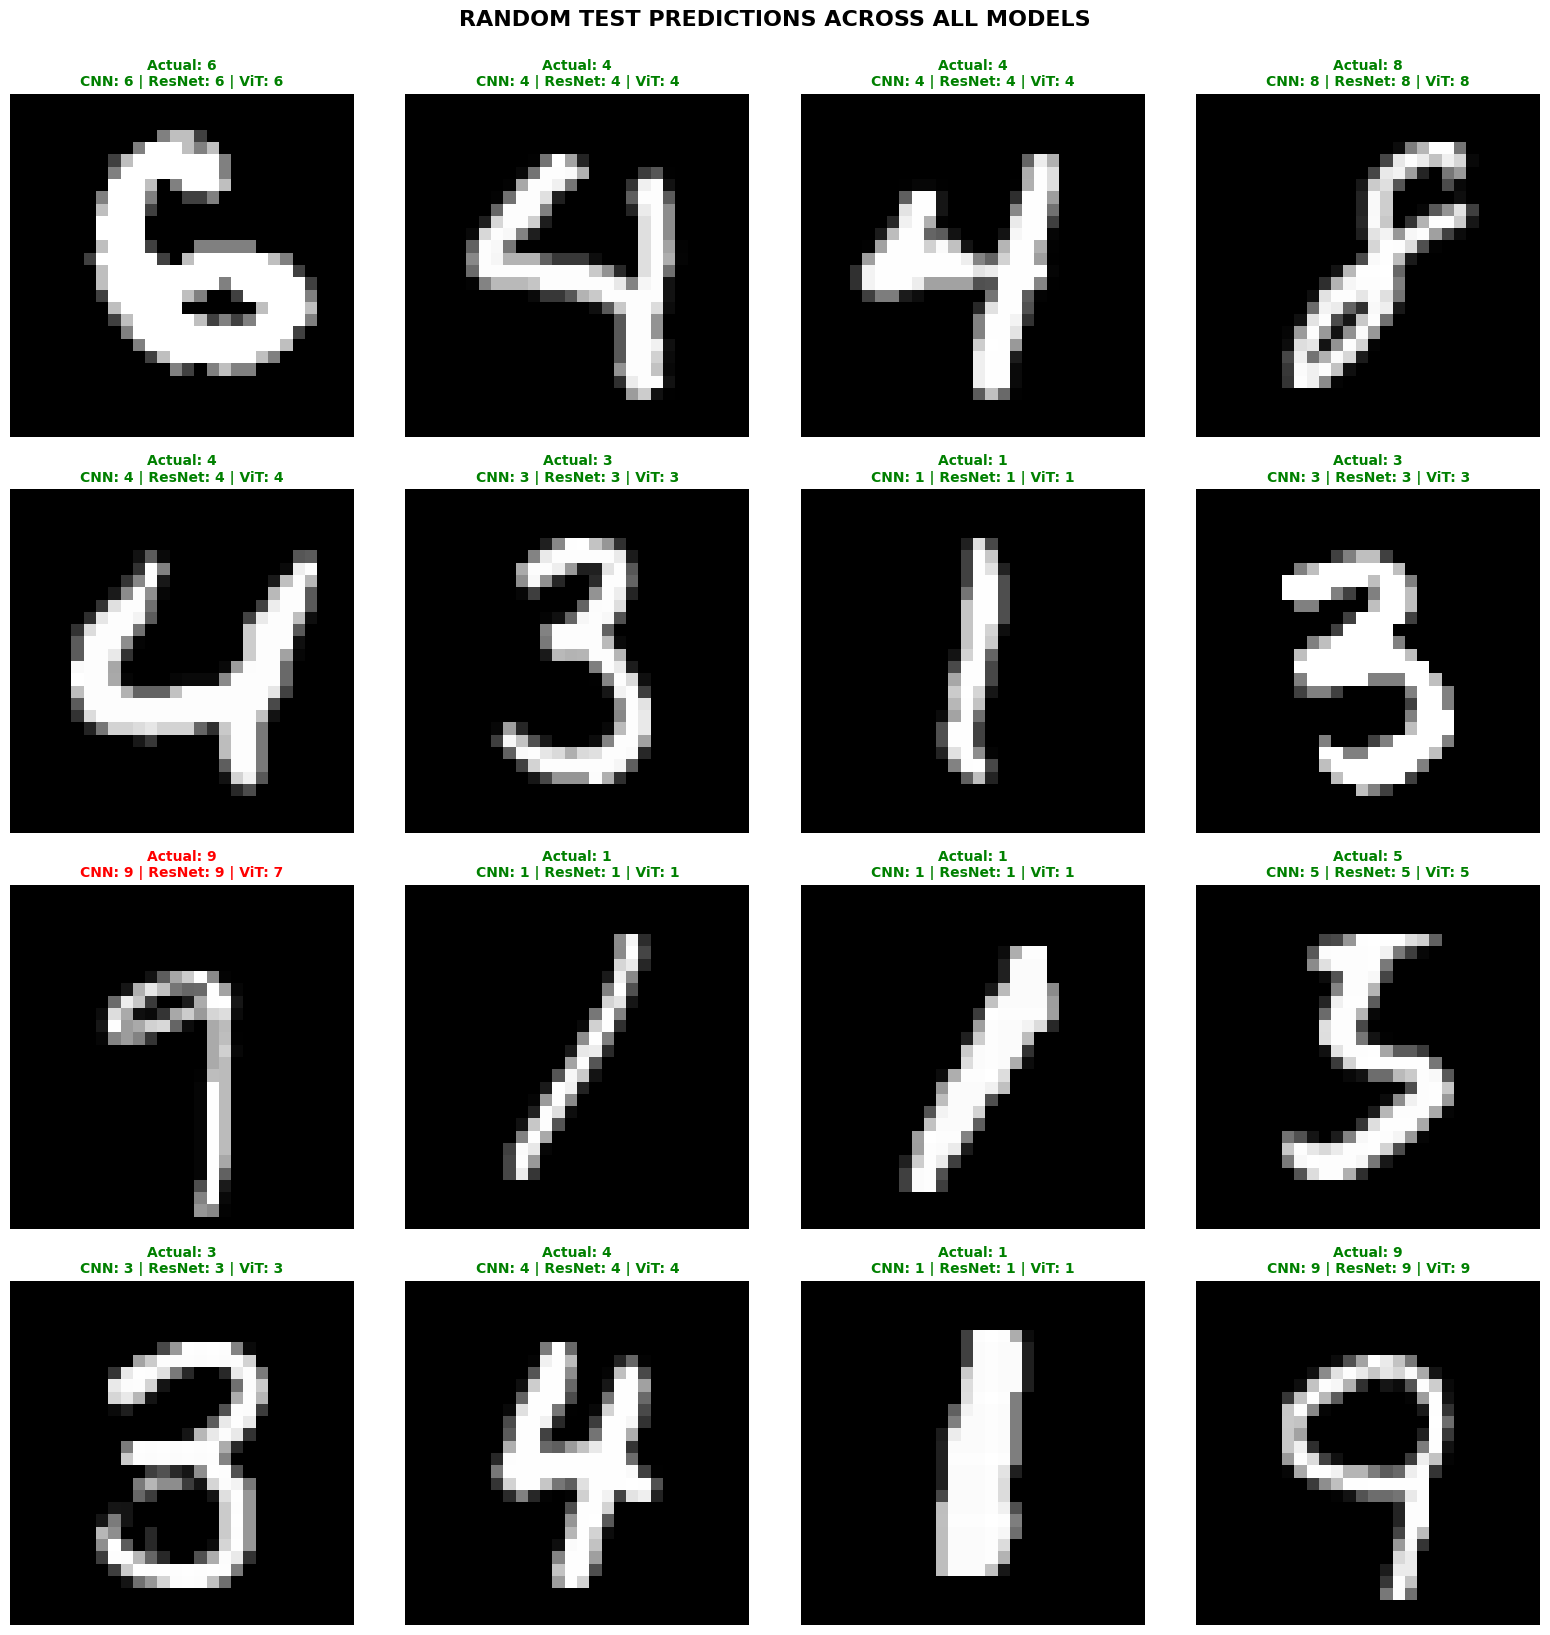

In [55]:
def plot_multi_model_predictions(X_test_images, y_true, pred_cnn, pred_resnet, pred_vit, num_rows=4, num_cols=4):
    """Plots a 4x4 grid of random test images with predictions from all 3 models."""
    total_images = len(X_test_images)
    random_indices = np.random.choice(total_images, size=(num_rows * num_cols), replace=False)

    fig, axes = plt.subplots(nrows=num_rows, ncols=num_cols, figsize=(16, 16))
    axes = axes.ravel()

    for i, idx in enumerate(random_indices):
        img = X_test_images[idx].reshape(28, 28)
        actual = y_true[idx]
        p_cnn = pred_cnn[idx]
        p_res = pred_resnet[idx]
        p_vit = pred_vit[idx]

        # Determine title color: green if ALL models are correct, red otherwise
        all_correct = (p_cnn == actual) and (p_res == actual) and (p_vit == actual)
        title_color = 'green' if all_correct else 'red'

        axes[i].imshow(img, cmap='gray')
        axes[i].axis('off')

        title_string = f"Actual: {actual}\nCNN: {p_cnn} | ResNet: {p_res} | ViT: {p_vit}"
        axes[i].set_title(title_string, color=title_color, fontsize=10, fontweight='bold', pad=6)

    plt.tight_layout()
    plt.suptitle("RANDOM TEST PREDICTIONS ACROSS ALL MODELS", fontsize=16, fontweight='bold', y=1.02)
    plt.show()

plot_multi_model_predictions(X_test_cnn, y_test, pred_standard, pred_resnet, pred_tinyvit)

## 4.5 Single Sample Deep Dive with Model Saving

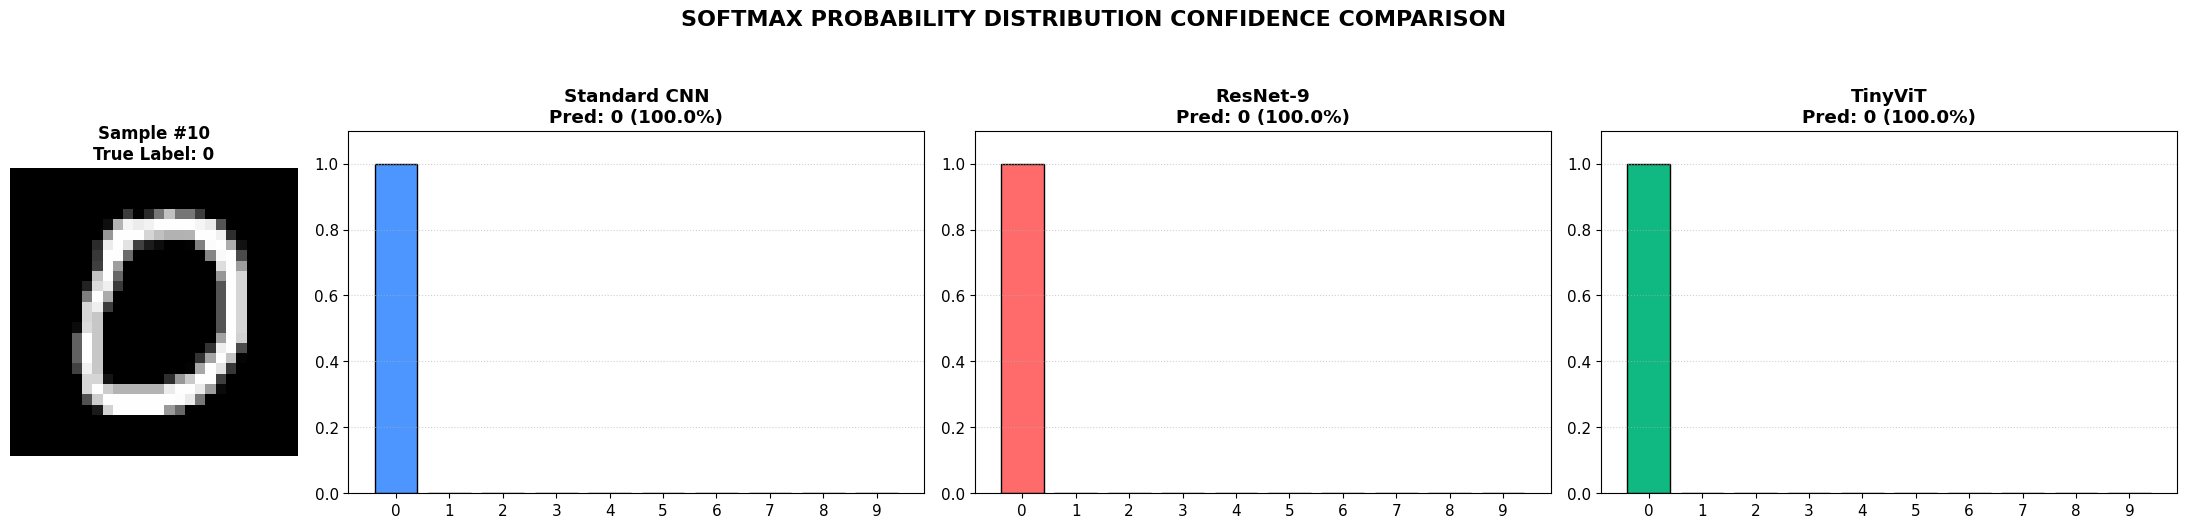


--- ALL MODELS SAVED SUCCESSFULLY FOR NEXT PHASES ---


In [56]:
sample_idx = 10
test_sample_image = X_test_cnn[sample_idx].reshape(28, 28)
actual_digit = y_test[sample_idx]

# 1. Get prediction probability distributions
prob_cnn = standard_cnn.predict(X_test_cnn[sample_idx:sample_idx+1], verbose=0)[0]
prob_res = resnet_model.predict(X_test_cnn[sample_idx:sample_idx+1], verbose=0)[0]
prob_vit = tinyvit_model.predict(X_test_cnn[sample_idx:sample_idx+1], verbose=0)[0]

fig, axes = plt.subplots(1, 4, figsize=(22, 5), gridspec_kw={'width_ratios': [1, 2, 2, 2]})

# Plot 1: Input Image
axes[0].imshow(test_sample_image, cmap='gray')
axes[0].set_title(f"Sample #{sample_idx}\nTrue Label: {actual_digit}", fontsize=12, fontweight='bold')
axes[0].axis('off')

# Common configuration for probability bar charts
classes = np.arange(10)
colors = {'cnn': '#4D96FF', 'resnet': '#FF6B6B', 'tinyvit': '#10B981'}

# Plot 2: Standard CNN Distribution
axes[1].bar(classes, prob_cnn, color=colors['cnn'], edgecolor='black')
axes[1].set_title(f"Standard CNN\nPred: {np.argmax(prob_cnn)} ({np.max(prob_cnn)*100:.1f}%)", fontweight='bold')
axes[1].set_xticks(classes)
axes[1].set_ylim(0, 1.1)
axes[1].grid(axis='y', linestyle=':', alpha=0.6)

# Plot 3: ResNet-9 Distribution
axes[2].bar(classes, prob_res, color=colors['resnet'], edgecolor='black')
axes[2].set_title(f"ResNet-9\nPred: {np.argmax(prob_res)} ({np.max(prob_res)*100:.1f}%)", fontweight='bold')
axes[2].set_xticks(classes)
axes[2].set_ylim(0, 1.1)
axes[2].grid(axis='y', linestyle=':', alpha=0.6)

# Plot 4: TinyViT Distribution
axes[3].bar(classes, prob_vit, color=colors['tinyvit'], edgecolor='black')
axes[3].set_title(f"TinyViT\nPred: {np.argmax(prob_vit)} ({np.max(prob_vit)*100:.1f}%)", fontweight='bold')
axes[3].set_xticks(classes)
axes[3].set_ylim(0, 1.1)
axes[3].grid(axis='y', linestyle=':', alpha=0.6)

plt.suptitle("SOFTMAX PROBABILITY DISTRIBUTION CONFIDENCE COMPARISON", fontsize=16, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()


# STEP 3: SAVE ALL MODELS FOR NEXT PHASES

standard_cnn.save('best_standard_cnn.keras')
resnet_model.save('best_resnet9.keras')
tinyvit_model.save('best_tinyvit.keras')

print("\n--- ALL MODELS SAVED SUCCESSFULLY FOR NEXT PHASES ---")

# 5. Explainable AI

## 5.1 XAI Objectives and Methodology

This section explains **why each model predicts a digit**, rather than reporting accuracy alone.

The analysis uses three complementary perspectives:

1. **Model-specific explanations**: nearest neighbors for KNN, pixel importance for Random Forest, occlusion for SVM, Grad-CAM for CNN/ResNet, and attention rollout for Tiny-ViT.
2. **Shared deep-learning attribution**: Saliency and Integrated Gradients are applied to CNN, ResNet-9, and Tiny-ViT using the same input images and target classes.
3. **Faithfulness and error analysis**: explanations are compared on correct, low-confidence, disagreement, and misclassified test samples.

All explanation functions receive one normalized image with shape `(28, 28, 1)`. Traditional ML adapters flatten it internally to `(1, 784)`.


## 5.2 Common Utilities and Reproducible Sample Selection

The following cells validate the variables created earlier in the notebook, register all models, construct pre-softmax logit models for gradient-based XAI, and select a fixed set of representative test images.


In [ ]:
# 5.2.1 Imports, reproducibility, and notebook-state validation
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models

XAI_RANDOM_SEED = 42
np.random.seed(XAI_RANDOM_SEED)
tf.random.set_seed(XAI_RANDOM_SEED)

required_variables = [
    "X_train_flat", "X_test_flat", "X_train_cnn", "X_test_cnn",
    "y_train", "y_test", "knn", "svm_pipeline", "rf",
    "standard_cnn", "resnet_model", "tinyvit_model"
]

missing_variables = [name for name in required_variables if name not in globals()]
if missing_variables:
    raise RuntimeError(
        "Run all notebook cells from Sections 1-4 first. Missing variables: "
        + ", ".join(missing_variables)
    )

assert X_train_flat.ndim == 2 and X_train_flat.shape[1] == 784
assert X_test_flat.ndim == 2 and X_test_flat.shape[1] == 784
assert X_train_cnn.shape[1:] == (28, 28, 1)
assert X_test_cnn.shape[1:] == (28, 28, 1)
assert len(X_test_cnn) == len(y_test)

ML_MODELS = {
    "KNN": knn,
    "SVM": svm_pipeline,
    "Random Forest": rf,
}

DL_MODELS = {
    "CNN": standard_cnn,
    "ResNet-9": resnet_model,
    "Tiny-ViT": tinyvit_model,
}

CNN_GRADCAM_LAYER = "target_activation"
RESNET_GRADCAM_LAYER = "res_block_2_out"

print("XAI environment is ready.")
print(f"ML models: {list(ML_MODELS.keys())}")
print(f"DL models: {list(DL_MODELS.keys())}")


In [ ]:
# 5.2.2 Common image preparation and prediction adapters
def prepare_xai_image(image):
    """Return one normalized MNIST image with shape (1, 28, 28, 1)."""
    image = np.asarray(image, dtype=np.float32)

    if image.shape == (784,):
        image = image.reshape(28, 28, 1)
    elif image.shape == (28, 28):
        image = image[..., np.newaxis]
    elif image.shape == (1, 28, 28):
        image = np.transpose(image, (1, 2, 0))
    elif image.shape == (1, 28, 28, 1):
        image = image[0]

    if image.shape != (28, 28, 1):
        raise ValueError(
            f"Expected (784,), (28,28), or (28,28,1); received {image.shape}."
        )

    # Keep compatibility with external uint8 images used later in Streamlit.
    if image.max() > 1.0:
        image = image / 255.0

    return image[np.newaxis, ...]


def flatten_xai_batch(images):
    """Convert image batch to the (N, 784) format used by ML models."""
    images = np.asarray(images, dtype=np.float32)
    if images.ndim == 3:
        images = images[np.newaxis, ...]
    return images.reshape(images.shape[0], -1)


def stable_softmax(scores):
    """Convert arbitrary class scores to a normalized display distribution."""
    scores = np.asarray(scores, dtype=np.float64)
    scores = scores - np.max(scores, axis=1, keepdims=True)
    exp_scores = np.exp(scores)
    return exp_scores / np.sum(exp_scores, axis=1, keepdims=True)


def predict_scores(model_name, images):
    """
    Return an (N, 10) class-score matrix.

    KNN/RF return native probabilities. SVM decision scores are transformed
    with softmax only for comparable visualization; they are not calibrated
    probabilities. Deep models return their softmax outputs.
    """
    images = np.asarray(images, dtype=np.float32)
    if images.ndim == 3:
        images = images[np.newaxis, ...]

    if model_name in DL_MODELS:
        return DL_MODELS[model_name](images, training=False).numpy()

    flat_images = flatten_xai_batch(images)
    model = ML_MODELS[model_name]

    if model_name in {"KNN", "Random Forest"}:
        return model.predict_proba(flat_images)

    if model_name == "SVM":
        return stable_softmax(model.decision_function(flat_images))

    raise KeyError(f"Unknown model name: {model_name}")


def predict_one(model_name, image):
    """Return predicted class, display confidence, and all class scores."""
    image_batch = prepare_xai_image(image)
    scores = predict_scores(model_name, image_batch)[0]
    predicted_class = int(np.argmax(scores))
    confidence = float(scores[predicted_class])
    return predicted_class, confidence, scores

# Smoke test with the notebook's existing sample index.
_smoke_image = X_test_cnn[sample_idx] if "sample_idx" in globals() else X_test_cnn[0]
for _name in list(ML_MODELS) + list(DL_MODELS):
    _pred, _confidence, _ = predict_one(_name, _smoke_image)
    print(f"{_name:<14} -> class {_pred}, display score {_confidence:.4f}")


In [ ]:
# 5.2.3 Build pre-softmax logit models for gradient-based explanations
def build_logit_model(probability_model):
    """
    Copy the trained final Dense layer without its softmax activation.
    The original model and its weights are not modified.
    """
    final_layer = probability_model.layers[-1]
    if not isinstance(final_layer, tf.keras.layers.Dense):
        raise TypeError(
            f"The final layer of {probability_model.name} must be Dense. "
            f"Received {type(final_layer).__name__}."
        )

    penultimate_output = probability_model.layers[-2].output
    linear_layer = layers.Dense(
        units=final_layer.units,
        activation=None,
        use_bias=final_layer.use_bias,
        name=f"{probability_model.name}_xai_logits"
    )
    logits = linear_layer(penultimate_output)

    logit_model = models.Model(
        inputs=probability_model.inputs,
        outputs=logits,
        name=f"{probability_model.name}_LogitModel"
    )
    linear_layer.set_weights(final_layer.get_weights())
    linear_layer.trainable = False
    return logit_model

DL_LOGIT_MODELS = {
    name: build_logit_model(model)
    for name, model in DL_MODELS.items()
}

# Verify that argmax(logits) matches argmax(softmax output).
verification_batch = X_test_cnn[:32]
for name, model in DL_MODELS.items():
    prob_pred = np.argmax(model(verification_batch, training=False).numpy(), axis=1)
    logit_pred = np.argmax(DL_LOGIT_MODELS[name](verification_batch, training=False).numpy(), axis=1)
    if not np.array_equal(prob_pred, logit_pred):
        raise RuntimeError(f"Logit reconstruction failed for {name}.")
    print(f"{name}: logit model verified on 32 test images.")


In [ ]:
# 5.2.4 Select reproducible XAI samples from the test set
DL_PROBABILITIES = {
    name: model(X_test_cnn, training=False).numpy()
    for name, model in DL_MODELS.items()
}
DL_PREDICTIONS = {
    name: np.argmax(probabilities, axis=1)
    for name, probabilities in DL_PROBABILITIES.items()
}

prediction_matrix = np.column_stack(list(DL_PREDICTIONS.values()))
all_correct_mask = np.all(prediction_matrix == y_test[:, None], axis=1)
disagreement_mask = np.any(
    prediction_matrix != prediction_matrix[:, [0]],
    axis=1
)
any_error_mask = np.any(prediction_matrix != y_test[:, None], axis=1)

# Mean confidence assigned to the true class across CNN, ResNet-9, and Tiny-ViT.
true_class_confidence = np.mean(
    np.column_stack([
        probs[np.arange(len(y_test)), y_test]
        for probs in DL_PROBABILITIES.values()
    ]),
    axis=1
)

# Mean top-1 minus top-2 margin. Smaller margin means greater ambiguity.
model_margins = []
for probs in DL_PROBABILITIES.values():
    sorted_probs = np.sort(probs, axis=1)
    model_margins.append(sorted_probs[:, -1] - sorted_probs[:, -2])
mean_margin = np.mean(np.column_stack(model_margins), axis=1)

# One high-confidence, unanimously correct example for each digit.
high_confidence_correct = []
for digit in range(10):
    candidates = np.where((y_test == digit) & all_correct_mask)[0]
    if len(candidates) == 0:
        continue
    best_index = candidates[np.argmax(true_class_confidence[candidates])]
    high_confidence_correct.append(int(best_index))

# Deterministic ranking for the remaining categories.
misclassified = np.where(any_error_mask)[0]
misclassified = misclassified[np.argsort(true_class_confidence[misclassified])][:8]

low_confidence = np.argsort(mean_margin)[:8]

disagreement = np.where(disagreement_mask)[0]
disagreement = disagreement[np.argsort(mean_margin[disagreement])][:8]

XAI_SAMPLE_INDICES = {
    "high_confidence_correct": high_confidence_correct,
    "misclassified": misclassified.astype(int).tolist(),
    "low_confidence": low_confidence.astype(int).tolist(),
    "model_disagreement": disagreement.astype(int).tolist(),
}

sample_rows = []
for category, indices in XAI_SAMPLE_INDICES.items():
    for idx in indices:
        sample_rows.append({
            "category": category,
            "index": idx,
            "true_label": int(y_test[idx]),
            "cnn_prediction": int(DL_PREDICTIONS["CNN"][idx]),
            "resnet_prediction": int(DL_PREDICTIONS["ResNet-9"][idx]),
            "tinyvit_prediction": int(DL_PREDICTIONS["Tiny-ViT"][idx]),
            "mean_margin": float(mean_margin[idx]),
        })

xai_sample_table = pd.DataFrame(sample_rows).drop_duplicates(
    subset=["category", "index"]
).reset_index(drop=True)

print("Selected XAI sample counts:")
for category, indices in XAI_SAMPLE_INDICES.items():
    print(f"  {category:<26}: {len(indices)}")

display(xai_sample_table.head(20))


In [ ]:
# 5.2.5 Visual inspection of the selected sample groups
def plot_xai_sample_group(category, max_images=8):
    indices = XAI_SAMPLE_INDICES[category][:max_images]
    if not indices:
        print(f"No samples available for category: {category}")
        return

    fig, axes = plt.subplots(1, len(indices), figsize=(2.7 * len(indices), 3.2))
    axes = np.atleast_1d(axes)

    for ax, idx in zip(axes, indices):
        ax.imshow(X_test_cnn[idx].squeeze(), cmap="gray")
        ax.set_title(
            f"idx={idx} | true={y_test[idx]}\n"
            f"C={DL_PREDICTIONS['CNN'][idx]} "
            f"R={DL_PREDICTIONS['ResNet-9'][idx]} "
            f"V={DL_PREDICTIONS['Tiny-ViT'][idx]}"
        )
        ax.axis("off")

    plt.suptitle(category.replace("_", " ").title(), fontweight="bold")
    plt.tight_layout()
    plt.show()

for _category in XAI_SAMPLE_INDICES:
    plot_xai_sample_group(_category)
